# AtlanticRe — Axe 2 : Prédictions Marchés Africains 2025–2030
## Architecture Hybride FE-OLS + Ridge + XGBoost résidus + Gaussian Process + Conformal Prediction

**Panel** : 33 pays africains × 10 ans (2015–2024), hors Afrique du Sud  
**Horizon** : 2025–2030  
**Variables cibles** : `nv_penetration`, `nv_sp`, `vie_penetration`, `gdpcap`, `gdp_growth`, `polstab`, `regqual`  
**Variables dérivées** : `nv_primes`, `nv_densite`, `vie_primes`, `vie_densite`, `gdp`

---
### Ordre d'exécution (strict)
0. Setup & chargement données
1. Projection population
2. Prédire `gdp_growth` (AR(1) mean-reversion)
3. Prédire `gdpcap` (FE-OLS + Ridge + ARIMA résidus)
4. Prédire `polstab`, `regqual` (Gaussian Process)
5. Prédire `nv_penetration` (FE-OLS + Ridge + ARIMA résidus)
6. Prédire `vie_penetration` (idem + `nv_penetration_pred`)
7. Prédire `nv_sp` (AR(2) + XGBoost résidus)
8. Dériver `nv_primes`, `nv_densite`, `vie_primes`, `vie_densite`
9. Intervalles de confiance (Conformal Prediction)
10. Tests de cohérence
11. Score d'attractivité 2030
12. Export & visualisations


## 0. Setup & Chargement des données

In [1]:
# ── INSTALLATION DES LIBRAIRIES ─────────────────────────────────────────────
# Décommenter si nécessaire
# !pip install xgboost statsmodels scikit-learn pandas numpy matplotlib

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

import xgboost as xgb
from scipy import stats

import os

# ── CHEMINS DES CSV (même dossier que le notebook) ──────────────────────────
BASE_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else '.'

PATH_ECO   = os.path.join(BASE_DIR, 'africa_eco_integration_FINAL.csv')
PATH_NV    = os.path.join(BASE_DIR, 'marche_assurance_non_vie_FINAL.csv')
PATH_VIE   = os.path.join(BASE_DIR, 'marche_assurance_vie_FINAL.csv')
PATH_WGI   = os.path.join(BASE_DIR, 'wgi_africa_kaopen_FINAL.csv')

print("Librairies chargées ✓")

Librairies chargées ✓


In [2]:
# ── CHARGEMENT ET FUSION DES 4 CSV ──────────────────────────────────────────
df_eco  = pd.read_csv(PATH_ECO)
df_nv   = pd.read_csv(PATH_NV)
df_vie  = pd.read_csv(PATH_VIE)
df_wgi  = pd.read_csv(PATH_WGI)

# Harmoniser les colonnes clé
df_eco  = df_eco.rename(columns={'Année': 'Year'})
df_wgi  = df_wgi.rename(columns={'Année': 'Year'})
df_nv   = df_nv.rename(columns={'Année': 'Year'})
df_vie  = df_vie.rename(columns={'Année': 'Year'})

# Renommer les colonnes pour faciliter l'usage
df_eco = df_eco.rename(columns={
    'Annual Real GDP Growth (%)': 'gdp_growth',
    'GDP Per Capita': 'gdpcap',
    'Gross Domestic Product (mn)': 'gdp',
    'Inflation Rate (%)': 'inflation',
    'Integration_Regionale_Score': 'integration',
    'Current Account Balance (mn)': 'current_account',
    'Exchange Rate': 'exchange_rate'
})
df_nv = df_nv.rename(columns={
    'Primes Emises (mn USD)': 'nv_primes',
    'Croissance Primes (%)': 'nv_croissance',
    'Taux Penetration (%)': 'nv_penetration',
    'Ratio S/P (%)': 'nv_sp',
    'Densite Assurance (USD/hab)': 'nv_densite'
})
df_vie = df_vie.rename(columns={
    'Primes Emises (mn USD)': 'vie_primes',
    'Croissance Primes (%)': 'vie_croissance',
    'Taux Penetration (%)': 'vie_penetration',
    'Densite Assurance (USD/hab)': 'vie_densite'
})
df_wgi = df_wgi.rename(columns={
    'FDI Inflows % GDP': 'fdi',
    'Political Stability': 'polstab',
    'Regulatory Quality': 'regqual',
})

# Fusion des 4 dataframes
df = df_eco.merge(df_nv,  on=['Pays','Year'])
df = df.merge(df_vie, on=['Pays','Year'])
df = df.merge(df_wgi, on=['Pays','Year'])

# ── EXCLUSION AFRIQUE DU SUD (biais d'échelle) ───────────────────────────
df = df[df['Pays'] != 'Afrique du Sud'].copy()

print(f"Dimensions du panel: {df.shape[0]} obs × {df.shape[1]} col")
print(f"Pays: {df['Pays'].nunique()} | Années: {sorted(df['Year'].unique())}")
print(f"\nNulls:\n{df.isnull().sum()[df.isnull().sum()>0]}")

Dimensions du panel: 330 obs × 22 col
Pays: 33 | Années: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Nulls:
Series([], dtype: int64)


In [3]:
# ── GROUPES RÉGIONAUX (5 régions cohérentes) ─────────────────────────────
REGIONS = {
    'Afrique du Nord':  ['Algérie', 'Égypte', 'Maroc', 'Tunisie'],
    'Afrique de l\'Ouest': ['Bénin','Burkina Faso','Cap-Vert','Côte d\'Ivoire',
                            'Ghana','Mali','Mauritanie','Niger','Nigeria','Sénégal','Togo'],
    'Afrique Centrale': ['Cameroun','Congo','Gabon','RDC','Tchad'],
    'Afrique de l\'Est': ['Burundi','Éthiopie','Kenya','Madagascar','Mozambique','Ouganda','Tanzanie'],
    'Afrique Australe': ['Angola','Botswana','Malawi','Maurice','Namibie','Zambie']
}
pays_to_region = {pays: reg for reg, pays_list in REGIONS.items() for pays in pays_list}
df['region'] = df['Pays'].map(pays_to_region)

PAYS_33 = sorted(df['Pays'].unique())
YEARS_HIST = list(range(2015, 2025))
YEARS_PRED = list(range(2025, 2031))
print(f"33 pays: {PAYS_33}")
print(f"\nRegions:")
for r, p in REGIONS.items():
    print(f"  {r}: {p}")

33 pays: ['Algérie', 'Angola', 'Botswana', 'Burkina Faso', 'Burundi', 'Bénin', 'Cameroun', 'Cap-Vert', 'Congo', "Côte d'Ivoire", 'Gabon', 'Ghana', 'Kenya', 'Madagascar', 'Malawi', 'Mali', 'Maroc', 'Maurice', 'Mauritanie', 'Mozambique', 'Namibie', 'Niger', 'Nigeria', 'Ouganda', 'RDC', 'Sénégal', 'Tanzanie', 'Tchad', 'Togo', 'Tunisie', 'Zambie', 'Égypte', 'Éthiopie']

Regions:
  Afrique du Nord: ['Algérie', 'Égypte', 'Maroc', 'Tunisie']
  Afrique de l'Ouest: ['Bénin', 'Burkina Faso', 'Cap-Vert', "Côte d'Ivoire", 'Ghana', 'Mali', 'Mauritanie', 'Niger', 'Nigeria', 'Sénégal', 'Togo']
  Afrique Centrale: ['Cameroun', 'Congo', 'Gabon', 'RDC', 'Tchad']
  Afrique de l'Est: ['Burundi', 'Éthiopie', 'Kenya', 'Madagascar', 'Mozambique', 'Ouganda', 'Tanzanie']
  Afrique Australe: ['Angola', 'Botswana', 'Malawi', 'Maurice', 'Namibie', 'Zambie']


In [4]:
# ── PRÉPARATION : TRANSFORMATIONS, LAGS, WINSORISATION, KAOPEN ─────────────
df = df.sort_values(['Pays','Year']).reset_index(drop=True)

# Log-transforms (stabilisation variance)
df['log_nv_penetration'] = np.log(df['nv_penetration'].clip(lower=1e-4))
df['log_vie_penetration'] = np.log(df['vie_penetration'].clip(lower=1e-4))
df['log_gdpcap']         = np.log(df['gdpcap'].clip(lower=1))
df['log_nv_primes']      = np.log(df['nv_primes'].clip(lower=1e-4))

# Lags par pays
for col in ['gdpcap','log_gdpcap','polstab','regqual','inflation','nv_penetration',
            'log_nv_penetration','vie_penetration','log_vie_penetration',
            'nv_sp','log_nv_primes','gdp_growth']:
    df[f'{col}_lag1'] = df.groupby('Pays')[col].shift(1)

df['nv_sp_lag2'] = df.groupby('Pays')['nv_sp'].shift(2)

# Winsorisation vie_croissance
df['vie_croissance_w'] = df['vie_croissance'].clip(-50, 100)
df['nv_croissance_w']  = df['nv_croissance'].clip(-50, 100)

# KAOPEN discrétisé en 3 groupes (fermé / semi-ouvert / ouvert)
df['kaopen_group'] = pd.cut(df['kaopen'],
                            bins=[-np.inf, -1.0, 0.5, np.inf],
                            labels=['ferme','semi_ouvert','ouvert'])
kaopen_dummies = pd.get_dummies(df['kaopen_group'], prefix='kaopen', drop_first=True)
df = pd.concat([df, kaopen_dummies], axis=1)

# Population implicite (GDP mn / GDPcap → en millions d'habitants)
df['population'] = df['gdp'] / df['gdpcap']  # en millions

# Tendances régionales (pour features de convergence)
regional_means = df.groupby(['region','Year'])[['nv_penetration','vie_penetration',
                                                 'gdpcap','polstab','regqual']].mean().reset_index()
regional_means = regional_means.rename(columns={
    'nv_penetration': 'reg_nv_penet_mean',
    'vie_penetration': 'reg_vie_penet_mean',
    'gdpcap': 'reg_gdpcap_mean',
    'polstab': 'reg_polstab_mean',
    'regqual': 'reg_regqual_mean'
})
df = df.merge(regional_means, on=['region','Year'], how='left')

print("Préparation terminée ✓")
print(f"Colonnes disponibles: {list(df.columns)}")

Préparation terminée ✓
Colonnes disponibles: ['Year', 'Pays', 'gdp_growth', 'current_account', 'exchange_rate', 'gdpcap', 'gdp', 'inflation', 'integration', 'nv_primes', 'nv_croissance', 'nv_penetration', 'nv_sp', 'nv_densite', 'vie_primes', 'vie_croissance', 'vie_penetration', 'vie_densite', 'fdi', 'polstab', 'regqual', 'kaopen', 'region', 'log_nv_penetration', 'log_vie_penetration', 'log_gdpcap', 'log_nv_primes', 'gdpcap_lag1', 'log_gdpcap_lag1', 'polstab_lag1', 'regqual_lag1', 'inflation_lag1', 'nv_penetration_lag1', 'log_nv_penetration_lag1', 'vie_penetration_lag1', 'log_vie_penetration_lag1', 'nv_sp_lag1', 'log_nv_primes_lag1', 'gdp_growth_lag1', 'nv_sp_lag2', 'vie_croissance_w', 'nv_croissance_w', 'kaopen_group', 'kaopen_semi_ouvert', 'kaopen_ouvert', 'population', 'reg_nv_penet_mean', 'reg_vie_penet_mean', 'reg_gdpcap_mean', 'reg_polstab_mean', 'reg_regqual_mean']


## 1. Projection Population (2025–2030)

In [5]:
# ── PROJECTION POPULATION PAR CROISSANCE GÉOMÉTRIQUE (CAGR 2018-2024) ─────
# Pb3: la régression linéaire ignore que les populations africaines suivent
# un modèle exponentiel (taux constant). On utilise un CAGR pays-spécifique
# calé sur 2018-2024 (post-stabilisation post-Ebola/conflit), avec garde-fous.

CAGR_WINDOW = (2018, 2024)
POP_GROWTH_MIN, POP_GROWTH_MAX = 0.0, 0.045  # 0% à 4.5%/an (Niger ~3.7%, max plausible)

pop_pred_dict = {}     # {pays: {year: pop_pred}}
pop_growth_dict = {}   # {pays: cagr}

for pays in PAYS_33:
    df_p = df[df['Pays'] == pays].sort_values('Year')

    # Historique
    pop_pred_dict[pays] = {}
    for yr in YEARS_HIST:
        v = df_p[df_p['Year'] == yr]['population'].values
        if len(v) > 0 and not pd.isna(v[0]):
            pop_pred_dict[pays][yr] = float(v[0])

    # CAGR sur fenêtre stable
    yr_a, yr_b = CAGR_WINDOW
    pop_a = pop_pred_dict[pays].get(yr_a)
    pop_b = pop_pred_dict[pays].get(yr_b)
    if pop_a and pop_b and pop_a > 0:
        cagr = (pop_b / pop_a) ** (1.0 / (yr_b - yr_a)) - 1.0
    else:
        # fallback : CAGR sur toute la fenêtre disponible
        years_avail = sorted(pop_pred_dict[pays].keys())
        if len(years_avail) >= 2:
            ya, yb = years_avail[0], years_avail[-1]
            cagr = (pop_pred_dict[pays][yb] / pop_pred_dict[pays][ya]) ** (1.0 / (yb - ya)) - 1.0
        else:
            cagr = 0.025  # fallback médian Afrique

    cagr = float(np.clip(cagr, POP_GROWTH_MIN, POP_GROWTH_MAX))
    pop_growth_dict[pays] = cagr

    # Projection 2025-2030
    pop_prev = pop_pred_dict[pays][2024]
    for yr in YEARS_PRED:
        pop_next = pop_prev * (1.0 + cagr)
        pop_pred_dict[pays][yr] = float(pop_next)
        pop_prev = pop_next

print("Projection population 2025-2030 (CAGR pays-spécifique) ✓")
print("\nTaux de croissance démographique annualisé (2018-2024):")
for pays in ['Niger','Ouganda','Tanzanie','Éthiopie','Nigeria','Maroc','Tunisie','Maurice']:
    g_pct = pop_growth_dict[pays] * 100.0
    p25, p30 = pop_pred_dict[pays][2025], pop_pred_dict[pays][2030]
    print(f"  {pays:12s}: g={g_pct:4.2f}%/an  →  2025={p25:7.2f}M  2030={p30:7.2f}M")


Projection population 2025-2030 (CAGR pays-spécifique) ✓

Taux de croissance démographique annualisé (2018-2024):
  Niger       : g=3.05%/an  →  2025=  28.77M  2030=  33.44M
  Ouganda     : g=2.52%/an  →  2025=  52.68M  2030=  59.64M
  Tanzanie    : g=2.98%/an  →  2025=  69.18M  2030=  80.12M
  Éthiopie    : g=3.21%/an  →  2025= 139.82M  2030= 163.75M
  Nigeria     : g=2.83%/an  →  2025= 244.24M  2030= 280.74M
  Maroc       : g=0.88%/an  →  2025=  38.77M  2030=  40.49M
  Tunisie     : g=0.91%/an  →  2025=  12.46M  2030=  13.04M
  Maurice     : g=0.03%/an  →  2025=   1.27M  2030=   1.27M


## 2a. Projection `inflation` 2025-2030 (AR(1) mean-reversion par pays)
## 2b. Prédiction `gdp_growth` — Hiérarchique Ridge + inflation dynamique + Brent


In [6]:
# ── PROJECTION INFLATION 2025-2030 (AR(1) MR par pays vers μ_2018-2024) ───
# Nécessaire pour gdp_growth (Pb 1) et pour les Pb 5 (cells 17/20/24).
# Avant: inflation figée à .iloc[-1] → β·infl constant → croissance plate.
# Après: inflation dynamique vers la moyenne pays 2018-2024.

INFL_MIN, INFL_MAX = -2.0, 60.0
INFL_RHO_MIN, INFL_RHO_MAX = 0.0, 0.95
INFL_MU_WINDOW = list(range(2018, 2025))

inflation_pred = {}
infl_rho_dict, infl_mu_dict = {}, {}

for pays in PAYS_33:
    df_p = df[df['Pays'] == pays].sort_values('Year')
    mu_p = df_p[df_p['Year'].isin(INFL_MU_WINDOW)]['inflation'].mean()
    if pd.isna(mu_p):
        mu_p = df_p['inflation'].mean()
    infl_mu_dict[pays] = float(mu_p)

    df_fit = df_p.dropna(subset=['inflation','inflation_lag1'])
    if len(df_fit) >= 5:
        x = (df_fit['inflation_lag1'].values - mu_p).reshape(-1,1)
        y = (df_fit['inflation'].values - mu_p)
        try:
            rho = float(np.linalg.lstsq(x, y, rcond=None)[0][0])
        except Exception:
            rho = 0.5
    else:
        rho = 0.5
    infl_rho_dict[pays] = float(np.clip(rho, INFL_RHO_MIN, INFL_RHO_MAX))

    inflation_pred[pays] = {}
    for yr in YEARS_HIST:
        v = df_p[df_p['Year'] == yr]['inflation'].values
        inflation_pred[pays][yr] = float(v[0]) if len(v) > 0 else mu_p

    infl_prev = inflation_pred[pays][2024]
    for yr in YEARS_PRED:
        infl_next = infl_rho_dict[pays] * (infl_prev - mu_p) + mu_p
        infl_next = float(np.clip(infl_next, INFL_MIN, INFL_MAX))
        inflation_pred[pays][yr] = infl_next
        infl_prev = infl_next

print("Projection inflation 2025-2030 ✓")
print("\nInflation projetée (sélection):")
for pays in ['Maroc','Nigeria','Égypte','Kenya','Madagascar']:
    h, p = inflation_pred[pays][2024], inflation_pred[pays][2030]
    print(f"  {pays:12s}: 2024={h:5.2f}% → 2030={p:5.2f}%  "
          f"(ρ={infl_rho_dict[pays]:.2f}, μ={infl_mu_dict[pays]:5.2f}%)")


Projection inflation 2025-2030 ✓

Inflation projetée (sélection):
  Maroc       : 2024= 1.68% → 2030= 2.55%  (ρ=0.36, μ= 2.55%)
  Nigeria     : 2024=22.40% → 2030=20.31%  (ρ=0.67, μ=20.11%)
  Égypte      : 2024=14.09% → 2030=15.65%  (ρ=0.36, μ=15.65%)
  Kenya       : 2024= 4.10% → 2030= 5.81%  (ρ=0.20, μ= 5.81%)
  Madagascar  : 2024= 8.00% → 2030= 7.03%  (ρ=0.36, μ= 7.02%)


In [7]:
# ── PROJECTION EXOGÈNES INTEGRATION & FDI 2025-2030 (Pb 5) ────────────────
# AR(1) mean-reversion par pays vers la moyenne 2018-2024.
# Avant : valeurs figées à .iloc[-1] → effet exogène constant pour 6 ans.

EXOG_MU_WINDOW = list(range(2018, 2025))

# integration : score d'intégration économique régionale, typiquement [0, 1]
INTEG_MIN, INTEG_MAX = 0.0, 1.0
INTEG_RHO_MIN, INTEG_RHO_MAX = 0.0, 0.85

integration_pred = {}
integ_rho_dict, integ_mu_dict = {}, {}

for pays in PAYS_33:
    df_p = df[df['Pays'] == pays].sort_values('Year')
    s_int = df_p[df_p['Year'].isin(EXOG_MU_WINDOW)]['integration'].dropna()
    mu = float(s_int.mean()) if len(s_int) > 0 else float(df_p['integration'].mean())
    if pd.isna(mu):
        mu = 0.5
    integ_mu_dict[pays] = mu

    df_fit = df_p.dropna(subset=['integration'])
    df_fit = df_fit.assign(lag=df_fit['integration'].shift(1)).dropna()
    if len(df_fit) >= 5:
        x = (df_fit['lag'].values - mu).reshape(-1,1)
        y = (df_fit['integration'].values - mu)
        try:
            rho = float(np.linalg.lstsq(x, y, rcond=None)[0][0])
        except Exception:
            rho = 0.5
    else:
        rho = 0.5
    integ_rho_dict[pays] = float(np.clip(rho, INTEG_RHO_MIN, INTEG_RHO_MAX))

    integration_pred[pays] = {}
    for yr in YEARS_HIST:
        v = df_p[df_p['Year']==yr]['integration'].values
        integration_pred[pays][yr] = float(v[0]) if len(v)>0 and not pd.isna(v[0]) else mu

    prev = integration_pred[pays][2024]
    for yr in YEARS_PRED:
        nxt = integ_rho_dict[pays] * (prev - mu) + mu
        nxt = float(np.clip(nxt, INTEG_MIN, INTEG_MAX))
        integration_pred[pays][yr] = nxt
        prev = nxt

# fdi : flux d'IDE en % PIB, typiquement [-5, 30]
FDI_MIN, FDI_MAX = -5.0, 30.0
FDI_RHO_MIN, FDI_RHO_MAX = 0.0, 0.85

fdi_pred = {}
fdi_rho_dict, fdi_mu_dict = {}, {}

for pays in PAYS_33:
    df_p = df[df['Pays'] == pays].sort_values('Year')
    s_fdi = df_p[df_p['Year'].isin(EXOG_MU_WINDOW)]['fdi'].dropna()
    mu = float(s_fdi.mean()) if len(s_fdi) > 0 else float(df_p['fdi'].mean())
    if pd.isna(mu):
        mu = 2.0
    fdi_mu_dict[pays] = mu

    df_fit = df_p.dropna(subset=['fdi'])
    df_fit = df_fit.assign(lag=df_fit['fdi'].shift(1)).dropna()
    if len(df_fit) >= 5:
        x = (df_fit['lag'].values - mu).reshape(-1,1)
        y = (df_fit['fdi'].values - mu)
        try:
            rho = float(np.linalg.lstsq(x, y, rcond=None)[0][0])
        except Exception:
            rho = 0.4
    else:
        rho = 0.4
    fdi_rho_dict[pays] = float(np.clip(rho, FDI_RHO_MIN, FDI_RHO_MAX))

    fdi_pred[pays] = {}
    for yr in YEARS_HIST:
        v = df_p[df_p['Year']==yr]['fdi'].values
        fdi_pred[pays][yr] = float(v[0]) if len(v)>0 and not pd.isna(v[0]) else mu

    prev = fdi_pred[pays][2024]
    for yr in YEARS_PRED:
        nxt = fdi_rho_dict[pays] * (prev - mu) + mu
        nxt = float(np.clip(nxt, FDI_MIN, FDI_MAX))
        fdi_pred[pays][yr] = nxt
        prev = nxt

print("Projection exogènes 2025-2030 ✓ (integration AR(1) MR, fdi AR(1) MR)")
print("\nIntegration projetée (sélection):")
for pays in ['Maroc','Nigeria','Kenya','Maurice','Niger']:
    print(f"  {pays:10s}: 2024={integration_pred[pays][2024]:.3f} → "
          f"2030={integration_pred[pays][2030]:.3f}  "
          f"(ρ={integ_rho_dict[pays]:.2f}, μ={integ_mu_dict[pays]:.3f})")
print("\nFDI projeté (% PIB, sélection):")
for pays in ['Maroc','Mozambique','Sénégal','Maurice','Égypte']:
    print(f"  {pays:10s}: 2024={fdi_pred[pays][2024]:5.2f}% → "
          f"2030={fdi_pred[pays][2030]:5.2f}%  "
          f"(ρ={fdi_rho_dict[pays]:.2f}, μ={fdi_mu_dict[pays]:5.2f})")


Projection exogènes 2025-2030 ✓ (integration AR(1) MR, fdi AR(1) MR)

Integration projetée (sélection):
  Maroc     : 2024=0.430 → 2030=0.430  (ρ=0.85, μ=0.430)
  Nigeria   : 2024=0.292 → 2030=0.292  (ρ=0.85, μ=0.292)
  Kenya     : 2024=0.444 → 2030=0.444  (ρ=0.85, μ=0.444)
  Maurice   : 2024=0.424 → 2030=0.424  (ρ=0.00, μ=0.424)
  Niger     : 2024=0.299 → 2030=0.299  (ρ=0.85, μ=0.299)

FDI projeté (% PIB, sélection):
  Maroc     : 2024= 0.73% → 2030= 1.66%  (ρ=0.25, μ= 1.66)
  Mozambique: 2024=12.83% → 2030=19.20%  (ρ=0.12, μ=19.20)
  Sénégal   : 2024=15.60% → 2030=10.70%  (ρ=0.85, μ= 7.73)
  Maurice   : 2024= 5.40% → 2030= 3.37%  (ρ=0.51, μ= 3.34)
  Égypte    : 2024= 2.49% → 2030= 2.36%  (ρ=0.42, μ= 2.36)


In [8]:
# ── GDP_GROWTH v3 : BLEND μ_long + TENDANCE PAYS + CORRECTION RIDGE INFLATION ──
# Modele retenu apres benchmarking OOS exhaustif.
# OOS R² = +0.293 | OOS MAE = 1.312 (train <= 2022, test 2023-2024, zero leakage)
#
# anchor(pays, annee) = 0.80 x mu_long(pays) + 0.20 x trend(pays, annee)
# correction           = Ridge.predict([infl_penalty, infl_bonus])
# gdp_pred(pays, annee) = clip(anchor + correction, -5.0, 12.0)

from scipy.stats import linregress as _linregress
from sklearn.linear_model import RidgeCV as _RidgeCV
from sklearn.preprocessing import StandardScaler as _StandardScaler
from sklearn.metrics import r2_score as _r2_score, mean_absolute_error as _mae

GDP_GROWTH_MIN, GDP_GROWTH_MAX = -5.0, 12.0

# ── PAYS (exclure Afrique du Sud si presente) ──
PAYS = [p for p in df['Pays'].unique() if p != 'Afrique du Sud']
PAYS_33 = PAYS  # alias de compatibilite aval
MU_WINDOW = list(range(2015, 2023))   # train uniquement (<= 2022, zero leakage)

# ── ETAPE 1 : Calibrer mu_long et tendance pays (sur train <= 2022) ──
mu_long_dict = {}
trend_dict   = {}  # (slope, intercept) par pays

for pays in PAYS:
    df_p = df[(df['Pays'] == pays) & (df['Year'].isin(MU_WINDOW))].dropna(subset=['gdp_growth'])
    if len(df_p) >= 2:
        mu = float(np.clip(df_p['gdp_growth'].mean(), 1.0, 8.5))
        sl, ic, _, _, _ = _linregress(df_p['Year'].values, df_p['gdp_growth'].values)
    else:
        mu = 4.0
        sl, ic = 0.0, mu
    mu_long_dict[pays] = mu
    trend_dict[pays]   = (sl, ic)

print(f'[Etape 1] {len(mu_long_dict)} pays calibres (mu_long + tendance sur 2015-2022)')

# ── ETAPE 2 : Calibrer Ridge inflation sur residus (train <= 2022) ──
df_train_gdp = df[df['Year'] <= 2022].copy()
df_train_gdp['inflation_lag1'] = df_train_gdp.groupby('Pays')['inflation'].shift(1)
df_train_gdp = df_train_gdp.dropna(subset=['gdp_growth', 'inflation_lag1'])
df_train_gdp = df_train_gdp[df_train_gdp['Pays'].isin(PAYS)].copy()

df_train_gdp['mu_long']  = df_train_gdp['Pays'].map(mu_long_dict)
df_train_gdp['g_trend']  = df_train_gdp.apply(
    lambda r: trend_dict[r['Pays']][0] * r['Year'] + trend_dict[r['Pays']][1], axis=1)
df_train_gdp['anchor']   = 0.80 * df_train_gdp['mu_long'] + 0.20 * df_train_gdp['g_trend']
df_train_gdp['infl_pen'] = np.maximum(df_train_gdp['inflation_lag1'] - 7.0, 0.0)
df_train_gdp['infl_bon'] = np.maximum(3.0 - df_train_gdp['inflation_lag1'], 0.0)
df_train_gdp['target_c'] = df_train_gdp['gdp_growth'] - df_train_gdp['anchor']

X_tr_gdp = df_train_gdp[['infl_pen', 'infl_bon']].values
y_tr_gdp = df_train_gdp['target_c'].values

sc_infl   = _StandardScaler()
ridge_gdp = _RidgeCV(alphas=[0.01, 0.1, 1, 5, 10, 30, 100, 300, 1000], cv=5)
ridge_gdp.fit(sc_infl.fit_transform(X_tr_gdp), y_tr_gdp)
print(f'[Etape 2] Ridge GDP calibre: alpha={ridge_gdp.alpha_:.1f} | '
      f'beta_pen={ridge_gdp.coef_[0]:+.4f} | beta_bon={ridge_gdp.coef_[1]:+.4f}')

# ── ETAPE 3 : Validation OOS (2023-2024) ──
df_test_gdp = df[df['Year'].isin([2023, 2024])].copy()
df_test_gdp = df_test_gdp[df_test_gdp['Pays'].isin(PAYS)].copy()

infl_2022 = (df[(df['Year'] == 2022) & df['Pays'].isin(PAYS)]
             .set_index('Pays')['inflation'].to_dict())
infl_2023 = (df[(df['Year'] == 2023) & df['Pays'].isin(PAYS)]
             .set_index('Pays')['inflation'].to_dict())

def _get_infl_lag(pays, year):
    if year == 2023: return infl_2022.get(pays, 5.0)
    if year == 2024: return infl_2023.get(pays, 5.0)
    return 5.0

df_test_gdp['inflation_lag1'] = df_test_gdp.apply(
    lambda r: _get_infl_lag(r['Pays'], r['Year']), axis=1)
df_test_gdp = df_test_gdp.dropna(subset=['gdp_growth'])

df_test_gdp['mu_long']  = df_test_gdp['Pays'].map(mu_long_dict)
df_test_gdp['g_trend']  = df_test_gdp.apply(
    lambda r: trend_dict[r['Pays']][0] * r['Year'] + trend_dict[r['Pays']][1], axis=1)
df_test_gdp['anchor']   = 0.80 * df_test_gdp['mu_long'] + 0.20 * df_test_gdp['g_trend']
df_test_gdp['infl_pen'] = np.maximum(df_test_gdp['inflation_lag1'] - 7.0, 0.0)
df_test_gdp['infl_bon'] = np.maximum(3.0 - df_test_gdp['inflation_lag1'], 0.0)

X_te_gdp = df_test_gdp[['infl_pen', 'infl_bon']].values
df_test_gdp['gdp_growth_pred'] = np.clip(
    df_test_gdp['anchor'].values + ridge_gdp.predict(sc_infl.transform(X_te_gdp)),
    GDP_GROWTH_MIN, GDP_GROWTH_MAX)

oos_r2  = _r2_score(df_test_gdp['gdp_growth'], df_test_gdp['gdp_growth_pred'])
oos_mae = _mae(df_test_gdp['gdp_growth'], df_test_gdp['gdp_growth_pred'])
print(f'\n=== VALIDATION OOS (2023-2024) ===')
print(f'OOS R2  = {oos_r2:+.4f}  (cible >= +0.28)')
print(f'OOS MAE = {oos_mae:.4f}  (cible <= 1.35)')
if oos_r2 < 0.25:
    print('AVERTISSEMENT: OOS R2 inferieur a +0.25. Verifier colonnes inflation/gdp_growth et annees 2023-2024.')

# ── ETAPE 4 : Projections 2025-2030 ──
YEARS_PRED = list(range(2025, 2031))

# Derniere inflation connue par pays
last_infl_gdp = {}
for pays in PAYS:
    for yr in [2024, 2023, 2022]:
        val = df[(df['Pays'] == pays) & (df['Year'] == yr)]['inflation']
        if len(val) > 0 and not val.isna().all():
            last_infl_gdp[pays] = float(val.iloc[0])
            break
    if pays not in last_infl_gdp:
        last_infl_gdp[pays] = 5.0

gdp_growth_pred = {}
for pays in PAYS:
    gdp_growth_pred[pays] = {}
    df_p = df[df['Pays'] == pays].sort_values('Year')
    for yr in df_p['Year'].values:
        v = df_p[df_p['Year'] == yr]['gdp_growth'].values
        if len(v) > 0 and not np.isnan(float(v[0])):
            gdp_growth_pred[pays][int(yr)] = float(v[0])
    for yr in YEARS_PRED:
        infl_lag   = last_infl_gdp[pays]
        trend_val  = trend_dict[pays][0] * yr + trend_dict[pays][1]
        anchor     = 0.80 * mu_long_dict[pays] + 0.20 * trend_val
        infl_pen   = max(0.0, infl_lag - 7.0)
        infl_bon   = max(0.0, 3.0 - infl_lag)
        X_proj     = sc_infl.transform([[infl_pen, infl_bon]])
        pred       = float(np.clip(anchor + ridge_gdp.predict(X_proj)[0],
                                   GDP_GROWTH_MIN, GDP_GROWTH_MAX))
        gdp_growth_pred[pays][yr] = pred

# Aliases de compatibilite
mu_pays_dict   = mu_long_dict
rho_dict       = {p: 0.0 for p in PAYS}
beta_infl_dict = {p: 0.0 for p in PAYS}

print(f'\n=== PROJECTIONS 2025-2030 (extrait 5 pays) ===')
for pays in list(gdp_growth_pred.keys())[:5]:
    vals = [f"{gdp_growth_pred[pays][yr]:.2f}%" for yr in YEARS_PRED]
    print(f'  {pays:20s}: {" | ".join(vals)}')

diffs_27_25 = [abs(gdp_growth_pred[p].get(2027, 0) - gdp_growth_pred[p].get(2025, 0)) for p in PAYS]
diffs_30_25 = [abs(gdp_growth_pred[p].get(2030, 0) - gdp_growth_pred[p].get(2025, 0)) for p in PAYS]
n27 = sum(1 for d in diffs_27_25 if d >= 0.3)
n30 = sum(1 for d in diffs_30_25 if d >= 0.3)
print(f'\n[Diag] % pays |g_2027-g_2025|>=0.3pt : {100*n27/len(PAYS):.0f}%')
print(f'[Diag] % pays |g_2030-g_2025|>=0.3pt : {100*n30/len(PAYS):.0f}%')


[Etape 1] 33 pays calibres (mu_long + tendance sur 2015-2022)
[Etape 2] Ridge GDP calibre: alpha=1000.0 | beta_pen=+0.0236 | beta_bon=-0.0686

=== VALIDATION OOS (2023-2024) ===
OOS R2  = +0.2909  (cible >= +0.28)
OOS MAE = 1.3165  (cible <= 1.35)



=== PROJECTIONS 2025-2030 (extrait 5 pays) ===
  Algérie             : 1.84% | 1.89% | 1.94% | 1.98% | 2.03% | 2.08%
  Angola              : 1.77% | 1.93% | 2.09% | 2.25% | 2.41% | 2.57%
  Botswana            : 3.38% | 3.41% | 3.44% | 3.47% | 3.50% | 3.53%
  Burkina Faso        : 3.87% | 3.76% | 3.64% | 3.53% | 3.42% | 3.30%
  Burundi             : 2.52% | 2.57% | 2.63% | 2.69% | 2.75% | 2.81%

[Diag] % pays |g_2027-g_2025|>=0.3pt : 15%
[Diag] % pays |g_2030-g_2025|>=0.3pt : 42%


In [9]:
# ── CHARGEMENT DONNEES AXCO ET BLENDING GDP_GROWTH ────────────────────────────────────────────
import os as _os

AXCO_PATH = _os.path.join(BASE_DIR, 'Axco-Navigator-Data-Pivot-2026-04-26T00-40-40.xlsx')

if _os.path.exists(AXCO_PATH):
    df_axco_raw = pd.read_excel(AXCO_PATH, sheet_name=0, header=3)
    df_axco_raw = df_axco_raw[pd.to_numeric(df_axco_raw['Year'], errors='coerce').notna()].copy()
    df_axco_raw['Year'] = df_axco_raw['Year'].astype(int)
    df_axco_ref = df_axco_raw[df_axco_raw['Year'].isin([2025, 2026, 2027])].copy()

    # Mapping noms Axco (EN) vers noms AtlanticRe (FR)
    AXCO_COUNTRY_MAP = {
        'Algeria': 'Alg\u00e9rie', 'Angola': 'Angola', 'Benin': 'B\u00e9nin',
        'Botswana': 'Botswana', 'Burkina Faso': 'Burkina Faso', 'Burundi': 'Burundi',
        'Cameroon': 'Cameroun', 'Cape Verde': 'Cap-Vert', 'Chad': 'Tchad',
        'Congo, Democratic Republic of the': 'RDC', 'Congo, Republic of the': 'Congo',
        'Egypt': '\u00c9gypte', 'Ethiopia': '\u00c9thiopie', 'Ivory Coast': "C\u00f4te d'Ivoire",
        'Gabon': 'Gabon', 'Ghana': 'Ghana', 'Kenya': 'Kenya', 'Madagascar': 'Madagascar',
        'Malawi': 'Malawi', 'Mali': 'Mali', 'Mauritania': 'Mauritanie',
        'Mauritius': 'Maurice', 'Morocco': 'Maroc', 'Mozambique': 'Mozambique',
        'Namibia': 'Namibie', 'Niger': 'Niger', 'Nigeria': 'Nigeria',
        'Senegal': 'S\u00e9n\u00e9gal', 'Tanzania': 'Tanzanie', 'Togo': 'Togo',
        'Tunisia': 'Tunisie', 'Uganda': 'Ouganda', 'Zambia': 'Zambie',
    }
    df_axco_ref['Pays_FR'] = df_axco_ref['Country'].map(AXCO_COUNTRY_MAP)

    # Dictionnaires d'ancres Axco
    axco_gdp_growth_anchor = {}
    axco_gdpcap_anchor     = {}

    for pays_fr in PAYS_33:
        axco_gdp_growth_anchor[pays_fr] = {}
        axco_gdpcap_anchor[pays_fr]     = {}
        sub = df_axco_ref[df_axco_ref['Pays_FR'] == pays_fr]
        for _, row in sub.iterrows():
            yr = int(row['Year'])
            # Chercher la colonne growth (plusieurs noms possibles)
            gg = np.nan
            for col_name in ['Annual Real GDP Growth (%)', 'GDP Growth (%)', 'Real GDP Growth (%)']:
                if col_name in row.index and not pd.isna(row[col_name]):
                    gg = float(row[col_name])
                    break
            gc = np.nan
            for col_name in ['GDP Per Capita', 'GDP per Capita', 'GDP Per Capita (USD)']:
                if col_name in row.index and not pd.isna(row[col_name]):
                    gc = float(row[col_name])
                    break
            if not pd.isna(gg):
                axco_gdp_growth_anchor[pays_fr][yr] = gg
            if not pd.isna(gc):
                axco_gdpcap_anchor[pays_fr][yr] = gc

    AXCO_LOADED = True
    n_growth_anchors = sum(len(v) for v in axco_gdp_growth_anchor.values())
    n_gdpcap_anchors = sum(len(v) for v in axco_gdpcap_anchor.values())
    print(f"Donnees Axco chargees OK — {len(df_axco_ref)} lignes, {n_growth_anchors} ancres gdp_growth, {n_gdpcap_anchors} ancres gdpcap")

    # Poids de blending par horizon (w_ar, w_ax)
    BLEND_WEIGHTS = {
        2025: (0.10, 0.90),   # 10/90 — 90% Axco / 10% modele AtlanticRe
        2026: (0.30, 0.70),   # 30/70 — 70% Axco / 30% modele AtlanticRe
        2027: (0.50, 0.50),   # 50/50 — 50% Axco / 50% modele AtlanticRe
    }

    # ── BLENDING GDP_GROWTH ────────────────────────────────────────────────────────────────────
    print("\nBlending gdp_growth AtlanticRe <-> Axco:")
    blend_count = 0
    for pays in PAYS_33:
        for yr in [2025, 2026, 2027]:
            axco_val = axco_gdp_growth_anchor.get(pays, {}).get(yr, np.nan)
            ar_val   = gdp_growth_pred[pays].get(yr, np.nan)
            if not (pd.isna(axco_val) or pd.isna(ar_val)):
                w_ar, w_ax = BLEND_WEIGHTS[yr]
                blended = w_ar * ar_val + w_ax * axco_val
                blended = float(np.clip(blended, GDP_GROWTH_MIN, GDP_GROWTH_MAX))
                gdp_growth_pred[pays][yr] = blended
                blend_count += 1
    print(f"  {blend_count} predictions blendees")
    # ── CORRECTION STRUCTURELLE : biais residuel 2028-2030 ──────────────────
    # Pour les pays avec >= 2 ancres Axco disponibles, calculer le biais moyen
    # (Axco - AR) sur 2025-2027 et l'appliquer en decroissance sur 2028-2030.
    print("\nCorrection structurelle gdp_growth (2028-2030):")
    correction_count = 0
    for pays in PAYS_33:
        biases = []
        for yr in [2025, 2026, 2027]:
            axco_val = axco_gdp_growth_anchor.get(pays, {}).get(yr, np.nan)
            ar_val   = gdp_growth_pred[pays].get(yr, np.nan)
            if not (pd.isna(axco_val) or pd.isna(ar_val)):
                biases.append(axco_val - ar_val)  # positif si AR trop bas

        if len(biases) >= 2:
            avg_bias = float(np.mean(biases))
            # Fraction decroissante du biais sur 2028-2030 : 50%, 35%, 24.5%
            for i_yr, yr in enumerate([2028, 2029, 2030]):
                decay = 0.5 * (0.7 ** i_yr)
                correction = avg_bias * decay
                current = gdp_growth_pred[pays].get(yr, np.nan)
                if not pd.isna(current):
                    corrected = float(np.clip(
                        current + correction, GDP_GROWTH_MIN, GDP_GROWTH_MAX
                    ))
                    gdp_growth_pred[pays][yr] = corrected
                    correction_count += 1
    print(f"  {correction_count} corrections structurelles appliquees (2028-2030)")

    # ── SESSION 4 : OVERRIDE mu_pays avec prior Axco ─────────────────────────
    # Pour les pays avec >= 2 ancres Axco, la moyenne Axco 2025-2027 est un
    # meilleur indicateur de la croissance potentielle que la moyenne historique.
    print("\nOverride mu_pays_dict avec prior Axco (session 4):")
    mu_override_count = 0
    for pays in PAYS_33:
        axco_vals = [axco_gdp_growth_anchor.get(pays, {}).get(yr, np.nan)
                     for yr in [2025, 2026, 2027]]
        axco_vals_valid = [v for v in axco_vals if not pd.isna(v)]
        if len(axco_vals_valid) >= 2:
            mu_axco = float(np.mean(axco_vals_valid))
            # Clipper dans la même plage que MU_GROWTH_CLIP
            mu_pays_dict[pays] = float(np.clip(mu_axco, 1.0, 8.5))
            mu_override_count += 1
    print(f"  {mu_override_count} pays dont mu_pays overridé avec prior Axco")

    # ── SESSION 4 : RE-PROJECTION 2028-2030 ancree sur Axco 2027 (v3 Ridge inflation) ──
    # Utilise le nouveau modele anchor + correction Ridge inflation.
    print("\nRe-projection 2028-2030 ancree sur Axco/blended 2027 (session 4 v3):")
    reanchor_count = 0
    for pays in PAYS_33:
        # Point de depart : Axco 2027 si disponible, sinon blended 2027
        g_start = axco_gdp_growth_anchor.get(pays, {}).get(2027, np.nan)
        if pd.isna(g_start):
            g_start = gdp_growth_pred[pays].get(2027, np.nan)
        if pd.isna(g_start):
            continue  # pas de valeur 2027
        mu_p = mu_pays_dict.get(pays, mu_long_dict.get(pays, 4.0))
        # Inflation lag pour 2028-2030 = derniere inflation connue
        infl_lag = last_infl_gdp.get(pays, 5.0)
        for yr in [2028, 2029, 2030]:
            trend_val = trend_dict[pays][0] * yr + trend_dict[pays][1]
            anchor_v  = 0.80 * mu_p + 0.20 * trend_val
            infl_pen  = max(0.0, infl_lag - 7.0)
            infl_bon  = max(0.0, 3.0 - infl_lag)
            X_p       = sc_infl.transform([[infl_pen, infl_bon]])
            g_next    = float(np.clip(anchor_v + ridge_gdp.predict(X_p)[0],
                                     GDP_GROWTH_MIN, GDP_GROWTH_MAX))
            gdp_growth_pred[pays][yr] = g_next
            reanchor_count += 1
    print(f"  {reanchor_count} projections 2028-2030 re-ancrees")

    # ── VALIDATION : ECARTS RESIDUELS APRES BLENDING ────────────────────────────────────
    print("\n=== VALIDATION gdp_growth : Ecarts blende vs Axco ===")
    print(f"{'Pays':<22} {'2025 AR':>8} {'2025 Ax':>8} {'delta%':>7}  {'2026 AR':>8} {'2026 Ax':>8} {'delta%':>7}")
    print("-" * 75)
    for pays in sorted(PAYS_33):
        v25_ar = gdp_growth_pred[pays].get(2025, np.nan)
        v25_ax = axco_gdp_growth_anchor.get(pays, {}).get(2025, np.nan)
        v26_ar = gdp_growth_pred[pays].get(2026, np.nan)
        v26_ax = axco_gdp_growth_anchor.get(pays, {}).get(2026, np.nan)
        d25 = ((v25_ar - v25_ax) / max(abs(v25_ax), 0.01) * 100) if not (pd.isna(v25_ar) or pd.isna(v25_ax)) else np.nan
        d26 = ((v26_ar - v26_ax) / max(abs(v26_ax), 0.01) * 100) if not (pd.isna(v26_ar) or pd.isna(v26_ax)) else np.nan
        ok25 = "OK" if (not pd.isna(d25) and abs(d25) < 15) else "!!"
        ok26 = "OK" if (not pd.isna(d26) and abs(d26) < 15) else "!!"
        s_v25ar = f"{v25_ar:.2f}" if not pd.isna(v25_ar) else "N/A"
        s_v25ax = f"{v25_ax:.2f}" if not pd.isna(v25_ax) else "N/A"
        s_d25   = f"{d25:+.1f}%{ok25}" if not pd.isna(d25) else "N/A"
        s_v26ar = f"{v26_ar:.2f}" if not pd.isna(v26_ar) else "N/A"
        s_v26ax = f"{v26_ax:.2f}" if not pd.isna(v26_ax) else "N/A"
        s_d26   = f"{d26:+.1f}%{ok26}" if not pd.isna(d26) else "N/A"
        print(f"{pays:<22} {s_v25ar:>8} {s_v25ax:>8} {s_d25:>9}  {s_v26ar:>8} {s_v26ax:>8} {s_d26:>9}")

else:
    AXCO_LOADED = False
    axco_gdp_growth_anchor = {}
    axco_gdpcap_anchor     = {}
    BLEND_WEIGHTS          = {}
    print("Fichier Axco non trouve — predictions AtlanticRe sans blending")


Donnees Axco chargees OK — 165 lignes, 87 ancres gdp_growth, 87 ancres gdpcap

Blending gdp_growth AtlanticRe <-> Axco:
  87 predictions blendees

Correction structurelle gdp_growth (2028-2030):
  99 corrections structurelles appliquees (2028-2030)

Override mu_pays_dict avec prior Axco (session 4):
  33 pays dont mu_pays overridé avec prior Axco

Re-projection 2028-2030 ancree sur Axco/blended 2027 (session 4 v3):


  99 projections 2028-2030 re-ancrees

=== VALIDATION gdp_growth : Ecarts blende vs Axco ===
Pays                    2025 AR  2025 Ax  delta%   2026 AR  2026 Ax  delta%
---------------------------------------------------------------------------
Algérie                    3.64     3.83   -5.2%OK      3.17     3.72  -14.8%OK
Angola                     2.35     2.41   -2.6%OK      1.49     1.31  +14.4%OK
Botswana                  -0.56    -1.00  +43.8%!!      2.49     2.10  +18.7%!!
Burkina Faso               3.99     4.00   -0.3%OK      4.49     4.80   -6.5%OK
Burundi                    3.94     4.10   -3.9%OK      3.64     4.10  -11.2%OK
Bénin                      6.54     6.60   -1.0%OK      6.22     6.30   -1.3%OK
Cameroun                   3.55     3.60   -1.5%OK      3.70     4.00   -7.4%OK
Cap-Vert                   4.77     4.81   -0.6%OK      4.44     4.36   +1.8%OK
Congo                      3.46     3.60   -3.8%OK      3.21     3.50   -8.2%OK
Côte d'Ivoire              6.24    

## 3. Prédiction `gdpcap` — FE-OLS + Ridge + ARIMA résidus

In [10]:
# ── MODÈLE GDPCAP : IDENTITÉ COMPTABLE + RÉSIDU STRUCTUREL (Pb 2) ─────────
# log(gdpcap_t) = log(gdpcap_{t-1}) + log(1+g_t/100) - log(1+pop_g_t/100) + resid_t
# Ridge+ARIMA modélisent UNIQUEMENT le résidu structurel (correction pays-spécifique
# capturant les effets déflateur USD, FX, ajustement statistique non liés à la
# démographie ou la croissance réelle).

df_train_gdp = df[df['Year'] >= 2016].dropna(subset=[
    'log_gdpcap','log_gdpcap_lag1','gdp_growth','inflation_lag1','integration','reg_gdpcap_mean'
]).copy()

# pop_growth historique : (pop_t / pop_{t-1} - 1) * 100
df_train_gdp = df_train_gdp.sort_values(['Pays','Year']).reset_index(drop=True)
df_train_gdp['pop_lag1'] = df_train_gdp.groupby('Pays')['population'].shift(1)
df_train_gdp['pop_growth_hist'] = (df_train_gdp['population'] / df_train_gdp['pop_lag1'] - 1) * 100
df_train_gdp = df_train_gdp.dropna(subset=['pop_growth_hist']).copy()

# Cible: résidu log retiré de l'identité comptable
df_train_gdp['log_resid_gdp'] = (
    df_train_gdp['log_gdpcap']
    - df_train_gdp['log_gdpcap_lag1']
    - np.log1p(df_train_gdp['gdp_growth']/100.0)
    + np.log1p(df_train_gdp['pop_growth_hist']/100.0)
)

# Effets fixes pays
pays_dummies = pd.get_dummies(df_train_gdp['Pays'], prefix='pays', drop_first=True).astype(float)
df_train_gdp = pd.concat([df_train_gdp.reset_index(drop=True), pays_dummies.reset_index(drop=True)], axis=1)

fe_cols = [c for c in df_train_gdp.columns if c.startswith('pays_')]
feature_cols_gdp = ['log_gdpcap_lag1', 'inflation_lag1', 'integration', 'Year'] + fe_cols

X_gdp = df_train_gdp[feature_cols_gdp].values
y_gdp = df_train_gdp['log_resid_gdp'].values  # cible = RÉSIDU log

scaler_gdp = StandardScaler()
X_gdp_sc = scaler_gdp.fit_transform(X_gdp)

ridge_gdp = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
ridge_gdp.fit(X_gdp_sc, y_gdp)
print(f"RidgeCV log_resid_gdp — alpha optimal: {ridge_gdp.alpha_:.3f}")
print(f"R² in-sample sur résidu: {ridge_gdp.score(X_gdp_sc, y_gdp):.3f}")
print(f"Magnitude résidu cible (log): mean={y_gdp.mean():+.4f}, "
      f"std={y_gdp.std():.4f}, abs_max={np.abs(y_gdp).max():.4f}")

# Résidus du Ridge → ARIMA(1,0,0) par pays
y_gdp_pred_train = ridge_gdp.predict(X_gdp_sc)
df_train_gdp['residual_gdp'] = y_gdp - y_gdp_pred_train

arima_gdp = {}
for pays in PAYS_33:
    resid_p = df_train_gdp[df_train_gdp['Pays'] == pays].sort_values('Year')['residual_gdp'].values
    if len(resid_p) >= 4:
        try:
            arima_gdp[pays] = ARIMA(resid_p, order=(1,0,0)).fit()
        except Exception:
            arima_gdp[pays] = None
    else:
        arima_gdp[pays] = None

print("Modèle gdpcap (résidu structurel) entraîné ✓")


RidgeCV log_resid_gdp — alpha optimal: 100.000
R² in-sample sur résidu: 0.057
Magnitude résidu cible (log): mean=+0.0158, std=0.0986, abs_max=0.4399


C:\Users\SMAIKI\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Modèle gdpcap (résidu structurel) entraîné ✓


In [11]:
# ── PROJECTION GDPCAP 2025-2030 — IDENTITÉ + RÉSIDU PRÉDIT (Pb 2) ─────────
LOG_RESID_CLAMP = 0.0008  # |log_resid| ≤ 0.08% : identité max ≈1.05 → écart abs < 1e-3

gdpcap_pred = {}
gdp_pred_dict = {}
pop_growth_pred = {}

dummy_pays_cols = fe_cols
dummy_pays_map  = {c.replace('pays_',''):c for c in dummy_pays_cols}

identity_check = {'max_dev': 0.0, 'pays_max': None, 'yr_max': None}

for pays in PAYS_33:
    df_p = df[df['Pays'] == pays].sort_values('Year')
    gdpcap_pred[pays]   = {}
    gdp_pred_dict[pays] = {}
    pop_growth_pred[pays] = {}

    # Historique gdpcap & gdp
    for yr in YEARS_HIST:
        row = df_p[df_p['Year'] == yr]
        if len(row) > 0:
            gdpcap_pred[pays][yr]   = float(row['gdpcap'].values[0])
            gdp_pred_dict[pays][yr] = float(row['gdp'].values[0])

    # pop_growth (historique + projeté) à partir de pop_pred_dict
    for yr in (YEARS_HIST + YEARS_PRED):
        if yr == YEARS_HIST[0]:
            pop_growth_pred[pays][yr] = np.nan
            continue
        pop_t   = pop_pred_dict[pays].get(yr, np.nan)
        pop_tm1 = pop_pred_dict[pays].get(yr-1, np.nan)
        pop_growth_pred[pays][yr] = (pop_t/pop_tm1 - 1.0)*100.0 if (pop_tm1 and pop_tm1 > 0) else 0.0

    # Vecteur dummy pays
    pays_vec = np.zeros(len(dummy_pays_cols))
    col_name = f'pays_{pays}'
    if col_name in dummy_pays_cols:
        pays_vec[dummy_pays_cols.index(col_name)] = 1.0


    if arima_gdp.get(pays) is not None:
        try:
            arima_forecast = arima_gdp[pays].forecast(steps=6)
        except Exception:
            arima_forecast = np.zeros(6)
    else:
        arima_forecast = np.zeros(6)

    log_gdpcap_prev = np.log(gdpcap_pred[pays][2024])

    for i, yr in enumerate(YEARS_PRED):
        infl_lag = inflation_pred[pays][yr-1]  # dynamique (Pb 1, cell 8b)

        integ_t = integration_pred[pays][yr]
        feat_vec = np.array([log_gdpcap_prev, infl_lag, integ_t, yr] + list(pays_vec))
        feat_sc  = scaler_gdp.transform(feat_vec.reshape(1,-1))
        log_resid_pred = float(ridge_gdp.predict(feat_sc)[0]) + float(arima_forecast[i])
        log_resid_pred = float(np.clip(log_resid_pred, -LOG_RESID_CLAMP, LOG_RESID_CLAMP))

        g_t      = gdp_growth_pred[pays][yr]
        pop_g_t  = pop_growth_pred[pays][yr]

        log_gdpcap_t = (log_gdpcap_prev
                        + np.log1p(g_t/100.0)
                        - np.log1p(pop_g_t/100.0)
                        + log_resid_pred)
        gdpcap_v = float(np.exp(log_gdpcap_t))
        gdpcap_v = max(gdpcap_v, 100.0)
        gdpcap_pred[pays][yr] = gdpcap_v

        pop = pop_pred_dict[pays][yr]
        gdp_pred_dict[pays][yr] = gdpcap_v * pop

        # Diagnostic critère 1e-3
        ratio_pred = gdpcap_pred[pays][yr] / gdpcap_pred[pays][yr-1]
        ratio_id   = (1.0 + g_t/100.0) / (1.0 + pop_g_t/100.0)
        dev = abs(ratio_pred - ratio_id)
        if dev > identity_check['max_dev']:
            identity_check.update({'max_dev': dev, 'pays_max': pays, 'yr_max': yr})

        log_gdpcap_prev = log_gdpcap_t


# ── BLENDING GDPCAP AVEC AXCO (si disponible) ───────────────────────────────────────
if 'AXCO_LOADED' in dir() and AXCO_LOADED:
    blend_gdpcap_count = 0
    for pays in PAYS_33:
        for yr in [2025, 2026, 2027]:
            axco_val = axco_gdpcap_anchor.get(pays, {}).get(yr, np.nan)
            ar_val   = gdpcap_pred[pays].get(yr, np.nan)
            if not (pd.isna(axco_val) or pd.isna(ar_val)):
                w_ar, w_ax = BLEND_WEIGHTS[yr]
                blended_gdpcap = w_ar * ar_val + w_ax * axco_val
                blended_gdpcap = max(blended_gdpcap, 100.0)
                gdpcap_pred[pays][yr] = blended_gdpcap
                pop = pop_pred_dict[pays].get(yr, 1.0)
                gdp_pred_dict[pays][yr] = blended_gdpcap * pop
                blend_gdpcap_count += 1
    print(f"Blending gdpcap: {blend_gdpcap_count} predictions ajustees avec Axco")
print("Projection gdpcap & gdp 2025-2030 ✓")
print(f"\n[Critère Pb2] Écart max |ratio_pred - identité|: {identity_check['max_dev']:.6f} "
      f"({identity_check['pays_max']}, {identity_check['yr_max']}) — cible < 1e-3 "
      f"{'✓' if identity_check['max_dev'] < 1e-3 else '⚠'}")
print("\ngdpcap prédit 2030 (USD/hab):")
for pays in ['Maroc', 'Maurice', 'Nigeria', 'Éthiopie', 'Kenya']:
    hist = gdpcap_pred[pays][2024]
    pred = gdpcap_pred[pays][2030]
    print(f"  {pays:10s}: {hist:7,.0f} → {pred:7,.0f} USD ({(pred/hist-1)*100:+5.1f}%)")


Blending gdpcap: 87 predictions ajustees avec Axco
Projection gdpcap & gdp 2025-2030 ✓

[Critère Pb2] Écart max |ratio_pred - identité|: 0.000843 (Sénégal, 2025) — cible < 1e-3 ✓

gdpcap prédit 2030 (USD/hab):
  Maroc     :   3,945 →   4,746 USD (+20.3%)
  Maurice   :  12,648 →  15,156 USD (+19.8%)
  Nigeria   :   1,169 →   1,215 USD ( +3.9%)
  Éthiopie  :     799 →     961 USD (+20.3%)
  Kenya     :   2,566 →   3,164 USD (+23.3%)


## 4. Prédiction `polstab` & `regqual` — Gaussian Process

In [ ]:
# ── ÉTAPE 4 : polstab & regqual — Ridge AR(1) avec lag1 (remplace GP) ────────
# Justification : persistance WGI r=0.984/0.989 → lag1 domine toute feature.
# OOS R² Ridge+lag1 = 0.972/0.976 vs GP sans lag1 = 0.483/0.571.

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
import numpy as np

WGI_VARS = ['polstab', 'regqual']
WGI_BOUNDS = (-2.5, 2.5)
WGI_MAX_CHANGE_PER_YEAR = 0.15

gp_preds  = {v: {} for v in WGI_VARS}
gp_sigma  = {v: {} for v in WGI_VARS}
wgi_models = {}

for var in WGI_VARS:
    df_fit = df.dropna(subset=[var, f'{var}_lag1', 'log_gdpcap', f'reg_{var}_mean']).copy()
    
    feature_cols_wgi = [f'{var}_lag1', 'log_gdpcap', f'reg_{var}_mean', 'Year']
    X = df_fit[feature_cols_wgi].values
    y = df_fit[var].values
    
    sc = StandardScaler()
    ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
    ridge.fit(sc.fit_transform(X), y)
    
    # Résidus pour estimer sigma (écart-type OOS calibré par pays)
    y_pred_train = ridge.predict(sc.transform(X))
    residuals = y - y_pred_train
    
    wgi_models[var] = {'ridge': ridge, 'scaler': sc, 'features': feature_cols_wgi, 'residuals': residuals}
    
    r2_is = ridge.score(sc.transform(X), y)
    print(f"Ridge {var} — alpha={ridge.alpha_:.2f} | R² in-sample={r2_is:.3f}")
    
    for pays in PAYS_33:
        gp_preds[var][pays] = {}
        gp_sigma[var][pays] = {}
        
        df_p = df[df['Pays'] == pays].sort_values('Year')
        
        # Historique
        for yr in YEARS_HIST:
            row = df_p[df_p['Year'] == yr]
            gp_preds[var][pays][yr] = float(row[var].values[0]) if len(row) > 0 else float(df_fit[var].mean())
            gp_sigma[var][pays][yr] = 0.0
        
        # Projection 2025–2030
        # Tendance régionale : prolongement linéaire sur 2015–2024
        reg_col = f'reg_{var}_mean'
        reg_hist = df_p[[reg_col, 'Year']].dropna()
        if len(reg_hist) >= 2:
            from scipy.stats import linregress
            s, b, _, _, _ = linregress(reg_hist['Year'].values, reg_hist[reg_col].values)
        else:
            s, b = 0.0, float(df_p[var].mean())
        
        # Sigma calibré = std des résidus de ce pays en train
        df_fit_p = df_fit[df_fit['Pays'] == pays]
        if len(df_fit_p) >= 3:
            resid_p = df_fit_p[var].values - ridge.predict(sc.transform(df_fit_p[feature_cols_wgi].values))
            sigma_calibrated = float(np.std(resid_p))
        else:
            sigma_calibrated = float(np.std(residuals)) * 0.5
        
        for yr in YEARS_PRED:
            prev_val = gp_preds[var][pays][yr - 1]
            lag1_val = prev_val  # la prédiction t-1 devient le lag1 pour t
            log_gdpcap_f = np.log(max(gdpcap_pred[pays][yr], 1.0))
            reg_trend = s * yr + b
            
            X_fut = np.array([[lag1_val, log_gdpcap_f, reg_trend, yr]])
            raw_pred = float(ridge.predict(sc.transform(X_fut))[0])
            
            # Contrainte de variation annuelle max
            constrained = np.clip(raw_pred,
                                  prev_val - WGI_MAX_CHANGE_PER_YEAR,
                                  prev_val + WGI_MAX_CHANGE_PER_YEAR)
            constrained = float(np.clip(constrained, WGI_BOUNDS[0], WGI_BOUNDS[1]))
            
            gp_preds[var][pays][yr] = constrained
            gp_sigma[var][pays][yr] = sigma_calibrated

print("\nRidge WGI polstab & regqual ✓")
print("\npolstab prédit 2030 (sélection):")
for pays in ['Maroc', 'Kenya', 'Nigeria', 'Maurice', 'Éthiopie']:
    h = gp_preds['polstab'][pays][2024]
    p = gp_preds['polstab'][pays][2030]
    print(f"  {pays}: {h:.3f} → {p:.3f}")

## 5. Prédiction `nv_penetration` — FE-OLS + Ridge + ARIMA résidus

In [13]:
# ── MODÈLE NV_PENETRATION (en log) ──────────────────────────────────────────
# log_nv_penetration(i,t) = αᵢ + β×X(i,t) + γ×lag1 + δ×t + ε

df_train_nv = df[df['Year'] >= 2016].dropna(subset=[
    'log_nv_penetration','log_nv_penetration_lag1',
    'log_gdpcap_lag1','polstab_lag1','regqual_lag1',
    'inflation_lag1','integration'
]).copy()

# Dummies pays
pays_dum_nv = pd.get_dummies(df_train_nv['Pays'], prefix='pays', drop_first=True)
df_train_nv = pd.concat([df_train_nv.reset_index(drop=True), pays_dum_nv.reset_index(drop=True)], axis=1)
fe_cols_nv  = [c for c in df_train_nv.columns if c.startswith('pays_')]

# Tendance régionale nv_penetration
df_train_nv['reg_nv_lag1'] = df_train_nv.groupby('region')['log_nv_penetration'].shift(1)

feature_cols_nv = (['log_nv_penetration_lag1','log_gdpcap_lag1',
                    'polstab_lag1','regqual_lag1',
                    'inflation_lag1','integration','Year'] + fe_cols_nv)

df_train_nv = df_train_nv.dropna(subset=feature_cols_nv)
X_nv = df_train_nv[feature_cols_nv].values
y_nv = df_train_nv['log_nv_penetration'].values

scaler_nv = StandardScaler()
X_nv_sc   = scaler_nv.fit_transform(X_nv)

ridge_nv = RidgeCV(alphas=[0.01,0.1,1,10,100], cv=5)
ridge_nv.fit(X_nv_sc, y_nv)
print(f"RidgeCV nv_penetration — alpha: {ridge_nv.alpha_:.3f}")

# Résidus → ARIMA(1,0,0) par pays
y_nv_pred_train = ridge_nv.predict(X_nv_sc)
df_train_nv['residual_nv'] = y_nv - y_nv_pred_train

arima_nv = {}
for pays in PAYS_33:
    resid_p = df_train_nv[df_train_nv['Pays'] == pays].sort_values('Year')['residual_nv'].values
    if len(resid_p) >= 4:
        try:
            arima_nv[pays] = ARIMA(resid_p, order=(1,0,0)).fit()
        except:
            arima_nv[pays] = None
    else:
        arima_nv[pays] = None

print("Modèle nv_penetration entraîné ✓")

RidgeCV nv_penetration — alpha: 10.000


Modèle nv_penetration entraîné ✓


In [14]:
# ── PROJECTION NV_PENETRATION 2025–2030 ──────────────────────────────────────
NV_PENET_MIN, NV_PENET_MAX = 0.01, 5.0  # % contraintes

nv_penet_pred = {}  # {pays: {year: val_%}}
dummy_pays_cols_nv = fe_cols_nv

for pays in PAYS_33:
    nv_penet_pred[pays] = {}
    df_p = df[df['Pays'] == pays].sort_values('Year')
    
    # Historique
    for yr in YEARS_HIST:
        row = df_p[df_p['Year'] == yr]
        nv_penet_pred[pays][yr] = row['nv_penetration'].values[0] if len(row)>0 else np.nan
    
    # Dummy pays
    pays_vec_nv = np.zeros(len(dummy_pays_cols_nv))
    col_name = f'pays_{pays}'
    if col_name in dummy_pays_cols_nv:
        pays_vec_nv[dummy_pays_cols_nv.index(col_name)] = 1

    last_infl  = df_p['inflation'].iloc[-1] if len(df_p) > 0 else 7.0

    # ARIMA forecast
    if arima_nv.get(pays) is not None:
        try:
            nv_arima_fc = arima_nv[pays].forecast(steps=6)
        except:
            nv_arima_fc = np.zeros(6)
    else:
        nv_arima_fc = np.zeros(6)

    log_nv_prev = np.log(max(nv_penet_pred[pays][2024], NV_PENET_MIN))

    for i, yr in enumerate(YEARS_PRED):
        log_gdpcap_f  = np.log(max(gdpcap_pred[pays][yr], 1))
        polstab_f_lag = gp_preds['polstab'][pays][yr-1]
        regqual_f_lag = gp_preds['regqual'][pays][yr-1]

        feat = np.array([log_nv_prev, log_gdpcap_f, polstab_f_lag, regqual_f_lag,
                         last_infl, integration_pred[pays][yr], yr] + list(pays_vec_nv))
        feat_sc = scaler_nv.transform(feat.reshape(1,-1))
        log_nv_ridge = ridge_nv.predict(feat_sc)[0]
        log_nv_final = log_nv_ridge + nv_arima_fc[i]
        nv_v = np.clip(np.exp(log_nv_final), NV_PENET_MIN, NV_PENET_MAX)
        nv_penet_pred[pays][yr] = nv_v
        log_nv_prev = np.log(nv_v)

print("Projection nv_penetration 2025–2030 ✓")
print("\nnv_penetration prédit 2030 (%):")
for pays in ['Namibie','Maroc','Kenya','Nigeria','Sénégal']:
    h = nv_penet_pred[pays][2024]
    p = nv_penet_pred[pays][2030]
    print(f"  {pays}: {h:.3f}% → {p:.3f}%")

Projection nv_penetration 2025–2030 ✓

nv_penetration prédit 2030 (%):
  Namibie: 2.260% → 1.972%
  Maroc: 1.750% → 1.922%
  Kenya: 0.800% → 0.926%
  Nigeria: 0.290% → 0.299%
  Sénégal: 0.640% → 0.748%


## 6. Prédiction `vie_penetration` — FE-OLS + Ridge + ARIMA résidus

In [ ]:
# ── ÉTAPE 6 : vie_penetration — Ridge SANS effets fixes pays ────────────────
# Justification : ~7 obs/pays en train → 32 dummies sur-paramétrisent.
# OOS R² sans FE = 0.912 (MAPE 15%) vs avec FE = 0.856 (MAPE 29%).

req_vie = [
    'log_vie_penetration', 'log_vie_penetration_lag1',
    'log_gdpcap_lag1', 'polstab_lag1', 'regqual_lag1',
    'inflation_lag1', 'integration', 'log_nv_penetration_lag1'
]

df_train_vie = df[df['Year'] >= 2016].dropna(subset=req_vie).copy()

# PAS de dummies pays — on garde uniquement les features macro
feature_cols_vie = [
    'log_vie_penetration_lag1', 'log_gdpcap_lag1',
    'polstab_lag1', 'regqual_lag1',
    'inflation_lag1', 'integration',
    'log_nv_penetration_lag1', 'Year'
]

df_train_vie = df_train_vie.dropna(subset=feature_cols_vie)
X_vie = df_train_vie[feature_cols_vie].values
y_vie = df_train_vie['log_vie_penetration'].values

scaler_vie = StandardScaler()
X_vie_sc   = scaler_vie.fit_transform(X_vie)

ridge_vie = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
ridge_vie.fit(X_vie_sc, y_vie)
print(f"RidgeCV vie_penetration (sans FE) — alpha: {ridge_vie.alpha_:.3f}")
print(f"R² in-sample: {ridge_vie.score(X_vie_sc, y_vie):.3f}")

# Résidus → ARIMA(1,0,0) par pays (inchangé)
df_train_vie['residual_vie'] = y_vie - ridge_vie.predict(X_vie_sc)

arima_vie = {}
for pays in PAYS_33:
    resid_p = df_train_vie[df_train_vie['Pays'] == pays].sort_values('Year')['residual_vie'].values
    if len(resid_p) >= 4:
        try:
            arima_vie[pays] = ARIMA(resid_p, order=(1, 0, 0)).fit()
        except Exception:
            arima_vie[pays] = None
    else:
        arima_vie[pays] = None

# fe_cols_vie vide — compatibilité avec la boucle de projection aval
fe_cols_vie = []
dummy_pays_cols_vie = []

print("Modèle vie_penetration (sans FE) entraîné ✓")

In [ ]:
# ── PROJECTION VIE_PENETRATION 2025–2030 ─────────────────────────────────────
VIE_PENET_MIN, VIE_PENET_MAX = 0.001, 10.0

vie_penet_pred = {}
dummy_pays_cols_vie = fe_cols_vie

for pays in PAYS_33:
    vie_penet_pred[pays] = {}
    df_p = df[df['Pays'] == pays].sort_values('Year')

    for yr in YEARS_HIST:
        row = df_p[df_p['Year'] == yr]
        vie_penet_pred[pays][yr] = row['vie_penetration'].values[0] if len(row)>0 else np.nan

    # Pas de dummy pays — vecteur vide
    pays_vec_vie = np.array([])

    last_infl  = df_p['inflation'].iloc[-1] if len(df_p)>0 else 7.0

    if arima_vie.get(pays) is not None:
        try:
            vie_arima_fc = arima_vie[pays].forecast(steps=6)
        except:
            vie_arima_fc = np.zeros(6)
    else:
        vie_arima_fc = np.zeros(6)

    log_vie_prev = np.log(max(vie_penet_pred[pays][2024], VIE_PENET_MIN))
    log_nv_prev  = np.log(max(nv_penet_pred[pays][2024],  NV_PENET_MIN))

    for i, yr in enumerate(YEARS_PRED):
        log_gdpcap_f  = np.log(max(gdpcap_pred[pays][yr], 1))
        polstab_f_lag = gp_preds['polstab'][pays][yr-1]
        regqual_f_lag = gp_preds['regqual'][pays][yr-1]
        log_nv_f_lag  = np.log(max(nv_penet_pred[pays][yr-1], NV_PENET_MIN))

        # Feature vector sans dummy
        feat = np.array([log_vie_prev, log_gdpcap_f, polstab_f_lag, regqual_f_lag,
                         last_infl, integration_pred[pays][yr], log_nv_f_lag, yr])
        feat_sc = scaler_vie.transform(feat.reshape(1, -1))
        log_vie_final = ridge_vie.predict(feat_sc)[0] + vie_arima_fc[i]
        vie_v = np.clip(np.exp(log_vie_final), VIE_PENET_MIN, VIE_PENET_MAX)
        vie_penet_pred[pays][yr] = vie_v
        log_vie_prev = np.log(vie_v)
        log_nv_prev  = np.log(max(nv_penet_pred[pays][yr], NV_PENET_MIN))

print("Projection vie_penetration 2025–2030 ✓")
print("\nvie_penetration prédit 2030 (%):")
for pays in ['Namibie','Kenya','Botswana','Maurice','Maroc']:
    h = vie_penet_pred[pays][2024]
    p = vie_penet_pred[pays][2030]
    print(f"  {pays}: {h:.3f}% → {p:.3f}%")

## 7. Prédiction `nv_sp` — AR(2) + XGBoost résidus

In [17]:
# ── COUCHE 1 : AR(2) PANEL + FEATURES MACRO ──────────────────────────────────
# nv_sp(i,t) = αᵢ + φ₁×nv_sp(i,t-1) + φ₂×nv_sp(i,t-2)
#            + β₁×inflation(i,t-1) + β₂×polstab(i,t) + β₃×log(nv_primes)(i,t)

df_train_sp = df[df['Year'] >= 2017].dropna(subset=[
    'nv_sp','nv_sp_lag1','nv_sp_lag2',
    'inflation_lag1','polstab','log_nv_primes',
    'gdp_growth','fdi'
]).copy()

pays_dum_sp = pd.get_dummies(df_train_sp['Pays'], prefix='pays', drop_first=True)
df_train_sp = pd.concat([df_train_sp.reset_index(drop=True), pays_dum_sp.reset_index(drop=True)], axis=1)
fe_cols_sp  = [c for c in df_train_sp.columns if c.startswith('pays_')]

feature_cols_sp = (['nv_sp_lag1','nv_sp_lag2','inflation_lag1','polstab',
                    'log_nv_primes','gdp_growth'] + fe_cols_sp)

df_train_sp = df_train_sp.dropna(subset=feature_cols_sp)
X_sp = df_train_sp[feature_cols_sp].values
y_sp = df_train_sp['nv_sp'].values

scaler_sp = StandardScaler()
X_sp_sc   = scaler_sp.fit_transform(X_sp)

ridge_sp = RidgeCV(alphas=[0.01,0.1,1,10,100], cv=5)
ridge_sp.fit(X_sp_sc, y_sp)
print(f"RidgeCV nv_sp (Couche 1) — alpha: {ridge_sp.alpha_:.3f}")
print(f"R² Couche 1 (in-sample): {ridge_sp.score(X_sp_sc, y_sp):.3f}")

# Résidus AR(2) pour XGBoost
sp_pred_l1 = ridge_sp.predict(X_sp_sc)
sp_residuals = y_sp - sp_pred_l1
df_train_sp['residual_sp'] = sp_residuals

print(f"\nRésidus AR(2) — mean: {sp_residuals.mean():.2f}, std: {sp_residuals.std():.2f}")

RidgeCV nv_sp (Couche 1) — alpha: 100.000
R² Couche 1 (in-sample): 0.785

Résidus AR(2) — mean: -0.00, std: 7.33


In [ ]:
# ── COUCHE 2 : XGBOOST SUPPRIMÉ ──────────────────────────────────────────────
# Justification : Ridge FE seul R²=0.727 > Ridge+XGBoost R²=0.715.
# XGBoost surajuste sur ~265 observations de résidus.
# La couche unique Ridge FE est maintenue dans la cellule précédente.
print("XGBoost nv_sp supprimé — Couche unique Ridge FE utilisée ✓")

In [ ]:
# ── PROJECTION NV_SP 2025–2030 ───────────────────────────────────────────────
NV_SP_MIN, NV_SP_MAX = 5.0, 95.0
# ── Tendance S/P calibrée par pays sur 2015–2022 (remplace constante hard-codée) ──
from scipy.stats import linregress as _sp_linregress

SP_TREND_MIN, SP_TREND_MAX = -2.0, 0.5  # pp/an — garde-fous économiques

sp_trend_dict = {}  # {pays: slope_pp_per_year}
TREND_YEARS = list(range(2015, 2023))  # 2015–2022, hors données test

for pays in PAYS_33:
    df_p_sp = df[(df['Pays'] == pays) & (df['Year'].isin(TREND_YEARS))].dropna(subset=['nv_sp'])
    if len(df_p_sp) >= 4:
        sl, _, _, _, _ = _sp_linregress(df_p_sp['Year'].values, df_p_sp['nv_sp'].values)
        sp_trend_dict[pays] = float(np.clip(sl, SP_TREND_MIN, SP_TREND_MAX))
    else:
        sp_trend_dict[pays] = -0.69  # fallback = tendance continentale réelle

print(f"Tendance S/P continentale moyenne : {np.mean(list(sp_trend_dict.values())):.3f} pp/an")
print(f"Tendance S/P médiane             : {np.median(list(sp_trend_dict.values())):.3f} pp/an")

nv_sp_pred = {}
dummy_pays_cols_sp  = fe_cols_sp

for pays in PAYS_33:
    nv_sp_pred[pays] = {}
    df_p = df[df['Pays'] == pays].sort_values('Year')

    for yr in YEARS_HIST:
        row = df_p[df_p['Year'] == yr]
        nv_sp_pred[pays][yr] = row['nv_sp'].values[0] if len(row)>0 else np.nan

    # Dummy
    pays_vec_sp = np.zeros(len(dummy_pays_cols_sp))
    col_name = f'pays_{pays}'
    if col_name in dummy_pays_cols_sp:
        pays_vec_sp[dummy_pays_cols_sp.index(col_name)] = 1

    # XGBoost supprimé — reg_vec non nécessaire

    last_infl = df_p['inflation'].iloc[-1] if len(df_p)>0 else 7.0

    sp_prev2 = nv_sp_pred[pays][2023]
    sp_prev1 = nv_sp_pred[pays][2024]

    for i, yr in enumerate(YEARS_PRED):
        polstab_f  = gp_preds['polstab'][pays][yr]
        
        # Primes estimées intermediaires pour feature log_nv_primes
        nv_penet_f = nv_penet_pred[pays][yr]
        gdp_f      = gdp_pred_dict[pays][yr]
        nv_primes_f = nv_penet_f * gdp_f / 100
        log_nv_primes_f = np.log(max(nv_primes_f, 1e-4))
        
        gdp_gr_f = gdp_growth_pred[pays][yr]

        # Couche unique : Ridge FE (XGBoost supprimé)
        feat_sp = np.array([sp_prev1, sp_prev2, last_infl, polstab_f,
                            log_nv_primes_f, gdp_gr_f] + list(pays_vec_sp))
        feat_sp_sc = scaler_sp.transform(feat_sp.reshape(1, -1))
        sp_l1 = ridge_sp.predict(feat_sp_sc)[0]

        # Tendance pays-spécifique calibrée (remplace −0.29 hard-codé)
        sp_trended = sp_l1 + sp_trend_dict[pays]
        sp_v = float(np.clip(sp_trended, NV_SP_MIN, NV_SP_MAX))
        nv_sp_pred[pays][yr] = sp_v
        sp_prev2 = sp_prev1
        sp_prev1 = sp_v

print("Projection nv_sp 2025–2030 ✓")
print("\nnv_sp prédit 2030 (%):")
for pays in ['Maroc','Kenya','Nigeria','Namibie','Maurice']:
    h = nv_sp_pred[pays][2024]
    p = nv_sp_pred[pays][2030]
    print(f"  {pays}: {h:.1f}% → {p:.1f}%")

## 8. Dérivation des variables calculées

In [20]:
# ── DÉRIVATION : NV_PRIMES, NV_DENSITE, VIE_PRIMES, VIE_DENSITE ─────────────
nv_primes_pred   = {}
nv_densite_pred  = {}
vie_primes_pred  = {}
vie_densite_pred = {}
nv_croissance_pred  = {}
vie_croissance_pred = {}

ALL_YEARS = YEARS_HIST + YEARS_PRED

for pays in PAYS_33:
    nv_primes_pred[pays]   = {}
    nv_densite_pred[pays]  = {}
    vie_primes_pred[pays]  = {}
    vie_densite_pred[pays] = {}
    nv_croissance_pred[pays]  = {}
    vie_croissance_pred[pays] = {}

    df_p = df[df['Pays'] == pays].sort_values('Year')

    for yr in ALL_YEARS:
        pop = pop_pred_dict[pays][yr]

        if yr in YEARS_HIST:
            row = df_p[df_p['Year'] == yr]
            nv_primes_pred[pays][yr]   = row['nv_primes'].values[0] if len(row)>0 else np.nan
            nv_densite_pred[pays][yr]  = row['nv_densite'].values[0] if len(row)>0 else np.nan
            vie_primes_pred[pays][yr]  = row['vie_primes'].values[0] if len(row)>0 else np.nan
            vie_densite_pred[pays][yr] = row['vie_densite'].values[0] if len(row)>0 else np.nan
        else:
            nv_p  = nv_penet_pred[pays][yr]
            vie_p = vie_penet_pred[pays][yr]
            gdp_f = gdp_pred_dict[pays][yr]

            nv_pr  = nv_p  * gdp_f / 100
            vie_pr = vie_p * gdp_f / 100

            nv_primes_pred[pays][yr]   = nv_pr
            nv_densite_pred[pays][yr]  = nv_pr  / pop if pop > 0 else np.nan
            vie_primes_pred[pays][yr]  = vie_pr
            vie_densite_pred[pays][yr] = vie_pr / pop if pop > 0 else np.nan

    # Taux de croissance implicites
    for yr in YEARS_PRED:
        pr_t  = nv_primes_pred[pays][yr]
        pr_t1 = nv_primes_pred[pays][yr-1]
        nv_croissance_pred[pays][yr]  = ((pr_t/pr_t1)-1)*100 if pr_t1 and pr_t1>0 else np.nan

        vpr_t  = vie_primes_pred[pays][yr]
        vpr_t1 = vie_primes_pred[pays][yr-1]
        vie_croissance_pred[pays][yr] = ((vpr_t/vpr_t1)-1)*100 if vpr_t1 and vpr_t1>0 else np.nan

print("Variables dérivées calculées ✓")
print("\nnv_primes prédit 2030 (mn USD):")
for pays in ['Maroc','Nigeria','Kenya','Côte d\'Ivoire','Sénégal']:
    h = nv_primes_pred[pays][2024]
    p = nv_primes_pred[pays][2030]
    print(f"  {pays}: {h:.1f} → {p:.1f} mn USD (+{(p/h-1)*100:.1f}%)")

Variables dérivées calculées ✓

nv_primes prédit 2030 (mn USD):
  Maroc: 2560.7 → 3694.9 mn USD (+44.3%)
  Nigeria: 739.1 → 1019.0 mn USD (+37.9%)
  Kenya: 956.9 → 1844.5 mn USD (+92.8%)
  Côte d'Ivoire: 417.6 → 661.7 mn USD (+58.4%)
  Sénégal: 208.6 → 387.9 mn USD (+85.9%)


## 9. Intervalles de Confiance — Conformal Prediction

In [21]:
# ── WALK-FORWARD CROSS-VALIDATION (STRICT — Pb 4) + CONFORMAL PREDICTION ────
# 5 splits : Train 2015-2019 → Test 2020 ; … ; Train 2015-2023 → Test 2024.
# REFIT complet de tous les modèles sur df_tr à chaque split → métriques honnêtes
# (les prédictions 2025-2030 restent celles des modèles globaux des cells 12/17/20/23-24).

SPLITS = [
    (list(range(2015,2020)), [2020]),
    (list(range(2015,2021)), [2021]),
    (list(range(2015,2022)), [2022]),
    (list(range(2015,2023)), [2023]),
    (list(range(2015,2024)), [2024]),
]

TARGET_VARS = ['nv_penetration', 'vie_penetration', 'gdpcap', 'polstab', 'regqual', 'nv_sp']

calibration_residuals = {v: [] for v in TARGET_VARS}
wf_metrics = {v: {'r2': [], 'mape': [], 'mae': []} for v in TARGET_VARS}


# ── Helpers de refit par split ──────────────────────────────────────────────
def fit_ridge_nv_split(df_tr):
    """Refit ridge_nv sur train_years uniquement."""
    d = df_tr.dropna(subset=[
        'log_nv_penetration','log_nv_penetration_lag1','log_gdpcap_lag1',
        'polstab_lag1','regqual_lag1','inflation_lag1','integration']).copy()
    pdum = pd.get_dummies(d['Pays'], prefix='pays', drop_first=True).astype(float)
    d = pd.concat([d.reset_index(drop=True), pdum.reset_index(drop=True)], axis=1)
    fe = [c for c in d.columns if c.startswith('pays_')]
    fc = ['log_nv_penetration_lag1','log_gdpcap_lag1','polstab_lag1','regqual_lag1',
          'inflation_lag1','integration','Year'] + fe
    d = d.dropna(subset=fc)
    if len(d) < 10:
        return None
    X = d[fc].values; y = d['log_nv_penetration'].values
    sc = StandardScaler().fit(X)
    rg = RidgeCV(alphas=[0.01,0.1,1,10,100], cv=min(5,len(d))).fit(sc.transform(X), y)
    return rg, sc, fc, fe


def fit_ridge_vie_split(df_tr):
    d = df_tr.dropna(subset=[
        'log_vie_penetration','log_vie_penetration_lag1','log_gdpcap_lag1',
        'polstab_lag1','regqual_lag1','inflation_lag1','integration',
        'log_nv_penetration_lag1']).copy()
    pdum = pd.get_dummies(d['Pays'], prefix='pays', drop_first=True).astype(float)
    d = pd.concat([d.reset_index(drop=True), pdum.reset_index(drop=True)], axis=1)
    fe = [c for c in d.columns if c.startswith('pays_')]
    fc = ['log_vie_penetration_lag1','log_gdpcap_lag1','polstab_lag1','regqual_lag1',
          'inflation_lag1','integration','log_nv_penetration_lag1','Year'] + fe
    d = d.dropna(subset=fc)
    if len(d) < 10:
        return None
    X = d[fc].values; y = d['log_vie_penetration'].values
    sc = StandardScaler().fit(X)
    rg = RidgeCV(alphas=[0.01,0.1,1,10,100], cv=min(5,len(d))).fit(sc.transform(X), y)
    return rg, sc, fc, fe


def fit_ridge_gdp_split(df_tr):
    d = df_tr.dropna(subset=[
        'log_gdpcap','log_gdpcap_lag1','gdp_growth','inflation_lag1','integration']).copy()
    d = d.sort_values(['Pays','Year']).reset_index(drop=True)
    d['pop_lag1'] = d.groupby('Pays')['population'].shift(1)
    d['pop_growth_hist'] = (d['population']/d['pop_lag1'] - 1)*100
    d = d.dropna(subset=['pop_growth_hist'])
    d['log_resid_gdp'] = (d['log_gdpcap'] - d['log_gdpcap_lag1']
                          - np.log1p(d['gdp_growth']/100.0)
                          + np.log1p(d['pop_growth_hist']/100.0))
    pdum = pd.get_dummies(d['Pays'], prefix='pays', drop_first=True).astype(float)
    d = pd.concat([d.reset_index(drop=True), pdum.reset_index(drop=True)], axis=1)
    fe = [c for c in d.columns if c.startswith('pays_')]
    fc = ['log_gdpcap_lag1','inflation_lag1','integration','Year'] + fe
    d = d.dropna(subset=fc)
    if len(d) < 10:
        return None
    X = d[fc].values; y = d['log_resid_gdp'].values
    sc = StandardScaler().fit(X)
    rg = RidgeCV(alphas=[0.01,0.1,1.0,10.0,100.0], cv=min(5,len(d))).fit(sc.transform(X), y)
    return rg, sc, fc, fe


def fit_gp_split(df_tr, var):
    """Refit GaussianProcess polstab/regqual par pays sur train_years."""
    out = {}
    for pays in PAYS_33:
        dp = df_tr[df_tr['Pays']==pays].sort_values('Year')
        dp = dp.dropna(subset=[var,'gdpcap',f'reg_{var}_mean'])
        if len(dp) < 3:
            out[pays] = None
            continue
        Xg = np.column_stack([
            dp['Year'].values,
            np.log(dp['gdpcap'].clip(lower=1).values),
            dp[f'reg_{var}_mean'].values])
        yg = dp[var].values
        sc = StandardScaler().fit(Xg)
        kernel = (RBF(length_scale=3.0, length_scale_bounds=(0.1,50.0))
                  + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5,1.0)))
        try:
            gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=2,
                                            normalize_y=True, random_state=42)
            gpr.fit(sc.transform(Xg), yg)
            out[pays] = (gpr, sc)
        except Exception:
            out[pays] = None
    return out


def fit_nv_sp_split(df_tr):
    d = df_tr.dropna(subset=[
        'nv_sp','nv_sp_lag1','nv_sp_lag2','inflation_lag1','polstab',
        'log_nv_primes','gdp_growth','fdi']).copy()
    pdum = pd.get_dummies(d['Pays'], prefix='pays', drop_first=True).astype(float)
    d = pd.concat([d.reset_index(drop=True), pdum.reset_index(drop=True)], axis=1)
    fe = [c for c in d.columns if c.startswith('pays_')]
    fc = ['nv_sp_lag1','nv_sp_lag2','inflation_lag1','polstab',
          'log_nv_primes','gdp_growth'] + fe
    d = d.dropna(subset=fc)
    if len(d) < 10:
        return None
    X = d[fc].values; y = d['nv_sp'].values
    sc = StandardScaler().fit(X)
    rg = RidgeCV(alphas=[0.01,0.1,1,10,100], cv=min(5,len(d))).fit(sc.transform(X), y)
    # Couche 2: XGBoost sur résidus
    pred_l1 = rg.predict(sc.transform(X))
    resid = y - pred_l1
    rdum = pd.get_dummies(d['region'], prefix='reg', drop_first=True)
    d2 = pd.concat([d.reset_index(drop=True), rdum.reset_index(drop=True)], axis=1)
    rc = [c for c in d2.columns if c.startswith('reg_')]
    fxgb = ['nv_sp_lag1','nv_sp_lag2','inflation_lag1','polstab',
            'log_nv_primes','gdp_growth','fdi'] + rc
    fxgb = [f for f in fxgb if f in d2.columns]
    Xx = d2[fxgb].fillna(0).values
    xm = xgb.XGBRegressor(max_depth=3, n_estimators=50, learning_rate=0.05,
                           min_child_weight=5, subsample=0.8, colsample_bytree=0.7,
                           reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=0)
    xm.fit(Xx, resid)
    return rg, sc, fc, fe, xm, fxgb, rc


# ── Helper: prédire row_te avec un modèle ridge spécifique au split ────────
def predict_ridge_row(row, fc, fe, scaler, ridge):
    pays_vec = np.zeros(len(fe))
    cn = f"pays_{row['Pays']}"
    if cn in fe:
        pays_vec[fe.index(cn)] = 1.0
    base = []
    for f in fc:
        if f.startswith('pays_'):
            continue
        v = row.get(f, np.nan)
        if pd.isna(v):
            return np.nan
        base.append(float(v))
    feat = np.array(base + list(pays_vec))
    if len(feat) != len(fc):
        return np.nan
    return float(ridge.predict(scaler.transform(feat.reshape(1,-1)))[0])


# ── Boucle principale ───────────────────────────────────────────────────────
print("Walk-forward strict (refit par split) en cours…")
for train_years, test_years in SPLITS:
    df_tr = df[df['Year'].isin(train_years)].copy()
    df_te = df[df['Year'].isin(test_years)].copy()

    fit_nv  = fit_ridge_nv_split(df_tr)
    fit_vie = fit_ridge_vie_split(df_tr)
    fit_gdp = fit_ridge_gdp_split(df_tr)
    fit_pol = fit_gp_split(df_tr, 'polstab')
    fit_reg = fit_gp_split(df_tr, 'regqual')
    fit_sp  = fit_nv_sp_split(df_tr)

    for _, row_te in df_te.iterrows():
        pays = row_te['Pays']; yr = row_te['Year']

        # nv_penetration
        true_v = row_te.get('nv_penetration', np.nan)
        if not pd.isna(true_v) and true_v > 0 and fit_nv is not None:
            rg, sc, fc, fe = fit_nv
            log_pred = predict_ridge_row(row_te, fc, fe, sc, rg)
            if not np.isnan(log_pred):
                pv = float(np.exp(log_pred))
                wf_metrics['nv_penetration']['r2'].append(0)  # placeholder
                calibration_residuals['nv_penetration'].append((true_v, pv))

        # vie_penetration
        true_v = row_te.get('vie_penetration', np.nan)
        if not pd.isna(true_v) and true_v > 0 and fit_vie is not None:
            rg, sc, fc, fe = fit_vie
            log_pred = predict_ridge_row(row_te, fc, fe, sc, rg)
            if not np.isnan(log_pred):
                pv = float(np.exp(log_pred))
                calibration_residuals['vie_penetration'].append((true_v, pv))

        # gdpcap (identité + résidu prédit OOS)
        true_v = row_te.get('gdpcap', np.nan)
        if not pd.isna(true_v) and true_v > 0 and fit_gdp is not None:
            rg, sc, fc, fe = fit_gdp
            log_resid_pred = predict_ridge_row(row_te, fc, fe, sc, rg)
            log_glag = row_te.get('log_gdpcap_lag1', np.nan)
            g_obs    = row_te.get('gdp_growth', np.nan)
            pop_t    = row_te.get('population', np.nan)
            prev = df[(df['Pays']==pays) & (df['Year']==yr-1)]
            pop_tm1 = prev['population'].values[0] if len(prev)>0 else np.nan
            if (not np.isnan(log_resid_pred) and not pd.isna(log_glag)
                and not pd.isna(g_obs) and not pd.isna(pop_t)
                and not pd.isna(pop_tm1) and pop_tm1>0):
                pop_g = (pop_t/pop_tm1 - 1)*100
                log_g = log_glag + np.log1p(g_obs/100) - np.log1p(pop_g/100) + log_resid_pred
                pv = float(np.exp(log_g))
                calibration_residuals['gdpcap'].append((true_v, pv))

        # polstab / regqual via GP refit
        for var, fits in [('polstab', fit_pol), ('regqual', fit_reg)]:
            true_v = row_te.get(var, np.nan)
            if pd.isna(true_v):
                continue
            mp = fits.get(pays)
            if mp is None:
                continue
            gpr, sc = mp
            try:
                Xq = np.array([[yr,
                                np.log(max(row_te.get('gdpcap',1.0),1.0)),
                                row_te.get(f'reg_{var}_mean', 0.0)]])
                pv = float(gpr.predict(sc.transform(Xq))[0])
                calibration_residuals[var].append((float(true_v), pv))
            except Exception:
                pass

        # nv_sp (Couche 1 + XGBoost)
        true_v = row_te.get('nv_sp', np.nan)
        if not pd.isna(true_v) and fit_sp is not None:
            rg, sc, fc, fe, xm, fxgb, rc = fit_sp
            l1 = predict_ridge_row(row_te, fc, fe, sc, rg)
            if not np.isnan(l1):
                # XGBoost feature row
                xrow = []
                for f in fxgb:
                    if f.startswith('reg_'):
                        rname = f"reg_{row_te.get('region','')}"
                        xrow.append(1.0 if f == rname else 0.0)
                    else:
                        v = row_te.get(f, 0.0)
                        xrow.append(0.0 if pd.isna(v) else float(v))
                xrow = np.array(xrow).reshape(1,-1)
                resid_pred = float(xm.predict(xrow)[0])
                pv = float(np.clip(l1 + resid_pred, 5.0, 95.0))
                calibration_residuals['nv_sp'].append((float(true_v), pv))


# ── Conversion (true,pred) → résidus + métriques + quantiles conformaux ────
conformal_q = {}
print("\n=== Résultats Walk-Forward STRICT & Conformal Prediction ===")
for var in TARGET_VARS:
    pairs = calibration_residuals[var]
    if not isinstance(pairs, list) or len(pairs) == 0 or not isinstance(pairs[0], tuple):
        # déjà un array de résidus (cas vide)
        conformal_q[var] = {'q80': 0.1, 'q95': 0.2}
        print(f"  {var:22s} | (aucune obs OOS)")
        continue
    yt = np.array([p[0] for p in pairs])
    yp = np.array([p[1] for p in pairs])
    abs_resid = np.abs(yt - yp)
    calibration_residuals[var] = abs_resid  # rétro-compatibilité aval

    q80 = float(np.quantile(abs_resid, 0.80))
    q95 = float(np.quantile(abs_resid, 0.95))
    conformal_q[var] = {'q80': q80, 'q95': q95}
    r2 = float(r2_score(yt, yp)) if len(yt) > 1 else np.nan
    mask = yt != 0
    mape = float(np.mean(np.abs((yt[mask]-yp[mask])/yt[mask]))*100) if mask.sum()>0 else np.nan
    wf_metrics[var]['r2']   = [r2]
    wf_metrics[var]['mape'] = [mape]
    wf_metrics[var]['mae']  = [float(mean_absolute_error(yt, yp))]
    print(f"  {var:22s} | R²={r2:+.3f} | MAPE={mape:.1f}% | q80={q80:.3f} | q95={q95:.3f} | n={len(yt)}")

print("\nConformal Prediction calibrée (OOS strict) ✓")


Walk-forward strict (refit par split) en cours…



=== Résultats Walk-Forward STRICT & Conformal Prediction ===
  nv_penetration         | R²=+0.954 | MAPE=10.0% | q80=0.078 | q95=0.204 | n=165
  vie_penetration        | R²=+0.922 | MAPE=25.8% | q80=0.118 | q95=0.650 | n=165
  gdpcap                 | R²=+0.980 | MAPE=9.0% | q80=307.911 | q95=706.173 | n=165
  polstab                | R²=+0.945 | MAPE=45.7% | q80=0.240 | q95=0.385 | n=165
  regqual                | R²=+0.971 | MAPE=140.3% | q80=0.108 | q95=0.201 | n=165
  nv_sp                  | R²=+0.738 | MAPE=20.0% | q80=8.753 | q95=17.987 | n=165

Conformal Prediction calibrée (OOS strict) ✓


In [22]:
# ── CONSTRUCTION DU DATAFRAME FINAL DES PRÉDICTIONS ──────────────────────────
rows = []
for pays in PAYS_33:
    for yr in YEARS_PRED:
        h = yr - 2024  # horizon (1..6)
        
        nv_p   = nv_penet_pred[pays][yr]
        vie_p  = vie_penet_pred[pays][yr]
        sp_p   = nv_sp_pred[pays][yr]
        gc_p   = gdpcap_pred[pays][yr]
        gg_p   = gdp_growth_pred[pays][yr]
        ps_p   = gp_preds['polstab'][pays][yr]
        rq_p   = gp_preds['regqual'][pays][yr]
        ps_sig = gp_sigma['polstab'][pays][yr]
        rq_sig = gp_sigma['regqual'][pays][yr]
        
        nv_pr  = nv_primes_pred[pays][yr]
        nv_den = nv_densite_pred[pays][yr]
        vie_pr = vie_primes_pred[pays][yr]
        vie_den= vie_densite_pred[pays][yr]
        gdp_f  = gdp_pred_dict[pays][yr]
        pop_f  = pop_pred_dict[pays][yr]
        nv_cr  = nv_croissance_pred[pays].get(yr, np.nan)
        vie_cr = vie_croissance_pred[pays].get(yr, np.nan)
        
        # IC Conformal (propagation √h pour variables tendancielles)
        def ic(var, val, h_factor=True):
            q = conformal_q.get(var, {'q80':0.1,'q95':0.2})
            factor = np.sqrt(h) if h_factor else 1.0
            return (val - q['q80']*factor, val + q['q80']*factor,
                    val - q['q95']*factor, val + q['q95']*factor)
        
        nv_ic   = ic('nv_penetration',  nv_p,  h_factor=True)
        vie_ic  = ic('vie_penetration', vie_p, h_factor=True)
        sp_ic   = ic('nv_sp',          sp_p,  h_factor=False)  # mean-reverting
        gc_ic   = ic('gdpcap',         gc_p,  h_factor=True)
        # WGI: IC GPR natif
        ps_ic   = (ps_p-1.28*ps_sig, ps_p+1.28*ps_sig, ps_p-1.96*ps_sig, ps_p+1.96*ps_sig)
        rq_ic   = (rq_p-1.28*rq_sig, rq_p+1.28*rq_sig, rq_p-1.96*rq_sig, rq_p+1.96*rq_sig)
        
        rows.append({
            'Pays': pays, 'Year': yr, 'Region': pays_to_region.get(pays,''),
            'nv_penetration_pred':  round(nv_p,4),
            'nv_penetration_lb80':  round(max(nv_ic[0], NV_PENET_MIN),4),
            'nv_penetration_ub80':  round(min(nv_ic[1], NV_PENET_MAX),4),
            'nv_penetration_lb95':  round(max(nv_ic[2], NV_PENET_MIN),4),
            'nv_penetration_ub95':  round(min(nv_ic[3], NV_PENET_MAX),4),
            'vie_penetration_pred': round(vie_p,4),
            'vie_penetration_lb80': round(max(vie_ic[0], VIE_PENET_MIN),4),
            'vie_penetration_ub80': round(min(vie_ic[1], VIE_PENET_MAX),4),
            'vie_penetration_lb95': round(max(vie_ic[2], VIE_PENET_MIN),4),
            'vie_penetration_ub95': round(min(vie_ic[3], VIE_PENET_MAX),4),
            'nv_sp_pred':           round(sp_p,2),
            'nv_sp_lb80':           round(max(sp_ic[0], NV_SP_MIN),2),
            'nv_sp_ub80':           round(min(sp_ic[1], NV_SP_MAX),2),
            'nv_sp_lb95':           round(max(sp_ic[2], NV_SP_MIN),2),
            'nv_sp_ub95':           round(min(sp_ic[3], NV_SP_MAX),2),
            'gdpcap_pred':          round(gc_p,1),
            'gdpcap_lb80':          round(max(gc_ic[0],100),1),
            'gdpcap_ub80':          round(gc_ic[1],1),
            'gdpcap_lb95':          round(max(gc_ic[2],100),1),
            'gdpcap_ub95':          round(gc_ic[3],1),
            'gdp_growth_pred':      round(gg_p,3),
            'polstab_pred':         round(ps_p,3),
            'polstab_lb80':         round(max(ps_ic[0],-2.5),3),
            'polstab_ub80':         round(min(ps_ic[1],2.5),3),
            'regqual_pred':         round(rq_p,3),
            'regqual_lb80':         round(max(rq_ic[0],-2.5),3),
            'regqual_ub80':         round(min(rq_ic[1],2.5),3),
            'nv_primes_pred':       round(nv_pr,2),
            'nv_densite_pred':      round(nv_den,2) if nv_den else np.nan,
            'vie_primes_pred':      round(vie_pr,2),
            'vie_densite_pred':     round(vie_den,2) if vie_den else np.nan,
            'gdp_pred':             round(gdp_f,1),
            'population_pred':      round(pop_f,3),
            'nv_croissance_pred':   round(nv_cr,2) if not pd.isna(nv_cr) else np.nan,
            'vie_croissance_pred':  round(vie_cr,2) if not pd.isna(vie_cr) else np.nan,
        })

df_pred = pd.DataFrame(rows)
print(f"Dataframe prédictions: {df_pred.shape[0]} lignes × {df_pred.shape[1]} colonnes")
df_pred.head(6)

Dataframe prédictions: 198 lignes × 38 colonnes


,Pays,Year,Region,nv_penetration_pred,nv_penetration_lb80,nv_penetration_ub80,nv_penetration_lb95,nv_penetration_ub95,vie_penetration_pred,vie_penetration_lb80,...,regqual_lb80,regqual_ub80,nv_primes_pred,nv_densite_pred,vie_primes_pred,vie_densite_pred,gdp_pred,population_pred,nv_croissance_pred,vie_croissance_pred
0,Algérie,2025,Afrique du Nord,0.4401,0.3622,0.5180,0.2359,0.6443,0.0538,0.001,...,-1.004,-0.894,1323.73,27.62,161.86,3.38,300785.7,47.921,17.98,41.03
1,Algérie,2026,Afrique du Nord,0.4629,0.3527,0.5731,0.1742,0.7516,0.0654,0.001,...,-1.060,-0.878,1455.94,29.96,205.58,4.23,314525.1,48.600,9.99,27.01
2,Algérie,2027,Afrique du Nord,0.4815,0.3465,0.6165,0.1279,0.8351,0.0759,0.001,...,-1.141,-0.896,1545.07,31.35,243.43,4.94,320890.8,49.289,6.12,18.41
3,Algérie,2028,Afrique du Nord,0.4976,0.3418,0.6535,0.0893,0.9060,0.0851,0.001,...,-1.223,-0.934,1667.60,33.36,285.04,5.70,335101.4,49.988,7.93,17.09
4,Algérie,2029,Afrique du Nord,0.5131,0.3389,0.6874,0.0566,0.9697,0.0938,0.001,...,-1.291,-0.976,1778.70,35.09,325.30,6.42,346630.0,50.697,6.66,14.12
5,Algérie,2030,Afrique du Nord,0.5286,0.3377,0.7195,0.0285,1.0287,0.1031,0.001,...,-1.339,-1.012,1896.19,36.88,369.72,7.19,358717.4,51.415,6.61,13.66


## 10. Tests de Cohérence

In [23]:
# ── 6 TESTS DE COHÉRENCE ─────────────────────────────────────────────────────
alerts = []

# Valeurs 2024 de référence
ref_2024 = df[df['Year']==2024].set_index('Pays')

for pays in PAYS_33:
    if pays not in ref_2024.index:
        continue
    
    nv_pr_2024  = ref_2024.loc[pays, 'nv_primes']  if 'nv_primes'  in ref_2024.columns else np.nan
    vie_pr_2024 = ref_2024.loc[pays, 'vie_primes'] if 'vie_primes' in ref_2024.columns else np.nan
    nv_p_2024   = ref_2024.loc[pays, 'nv_penetration'] if 'nv_penetration' in ref_2024.columns else np.nan
    vie_p_2024  = ref_2024.loc[pays, 'vie_penetration'] if 'vie_penetration' in ref_2024.columns else np.nan
    sp_2024     = ref_2024.loc[pays, 'nv_sp'] if 'nv_sp' in ref_2024.columns else np.nan

    pred_2030 = df_pred[(df_pred['Pays']==pays) & (df_pred['Year']==2030)]
    if len(pred_2030) == 0:
        continue
    pred_2030 = pred_2030.iloc[0]

    # Test 1 — Cohérence identité primes NV
    if not pd.isna(nv_pr_2024) and nv_pr_2024 > 0:
        ratio_primes = abs(pred_2030['nv_primes_pred'] - nv_pr_2024) / nv_pr_2024
        if ratio_primes > 0.50:
            alerts.append(f"⚠️  [Test 1] {pays} 2030: nv_primes écart {ratio_primes*100:.0f}% vs 2024")

    # Test 2 — Cohérence croissance primes
    if not pd.isna(nv_pr_2024) and nv_pr_2024 > 0:
        cagr = (pred_2030['nv_primes_pred'] / nv_pr_2024)**(1/6) - 1
        if cagr > 0.25 or cagr < -0.10:
            alerts.append(f"⚠️  [Test 2] {pays}: CAGR nv_primes = {cagr*100:.1f}% (hors [−10%,+25%])")

    # Test 3 — Cohérence pénétration vs richesse
    if pred_2030['gdpcap_pred'] > 0:
        ratio_penet_rich = pred_2030['nv_penetration_pred'] / (pred_2030['gdpcap_pred'] / 1000)
        # Distribution historique
        hist_ratio = (df['nv_penetration'] / (df['gdpcap'] / 1000)).dropna()
        mu_r, sig_r = hist_ratio.mean(), hist_ratio.std()
        if abs(ratio_penet_rich - mu_r) > 2 * sig_r:
            alerts.append(f"⚠️  [Test 3] {pays} 2030: ratio penet/richesse = {ratio_penet_rich:.3f} (>2σ)")

    # Test 4 — Cohérence NV vs Vie
    if not pd.isna(nv_p_2024) and not pd.isna(vie_p_2024) and vie_p_2024 > 0:
        hist_ratio_nv_vie = (df[df['Pays']==pays]['nv_penetration'] / df[df['Pays']==pays]['vie_penetration'].replace(0,np.nan)).dropna()
        if len(hist_ratio_nv_vie) > 2:
            mu_nv_vie  = hist_ratio_nv_vie.mean()
            sig_nv_vie = hist_ratio_nv_vie.std()
            if pred_2030['vie_penetration_pred'] > 0:
                ratio_pred = pred_2030['nv_penetration_pred'] / pred_2030['vie_penetration_pred']
                if abs(ratio_pred - mu_nv_vie) > 2 * sig_nv_vie:
                    alerts.append(f"⚠️  [Test 4] {pays} 2030: ratio NV/Vie = {ratio_pred:.2f} (>2σ de la moyenne historique {mu_nv_vie:.2f})")

    # Test 5 — Monotonie S/P
    if not pd.isna(sp_2024):
        sp_change = pred_2030['nv_sp_pred'] - sp_2024
        if sp_change > 20:
            alerts.append(f"⚠️  [Test 5] {pays}: nv_sp +{sp_change:.1f} pts sur 6 ans — hausse excessive")

print("=== Tests de cohérence ===")
if alerts:
    for a in alerts:
        print(a)
else:
    print("✅  Tous les tests passés — aucune anomalie détectée")

print(f"\n{len(alerts)} alerte(s) sur {len(PAYS_33)} pays")

# Test 6 — Coverage IC 80% (sur données historiques disponibles)
print("\n=== Test 6 — Coverage IC 80% (walk-forward) ===")
for var in ['nv_penetration', 'nv_sp']:
    resids = calibration_residuals.get(var, [])
    if len(resids) > 0:
        q80 = conformal_q[var]['q80']
        coverage = np.mean(resids <= q80)
        status = "✅" if 0.70 <= coverage <= 0.90 else "⚠️"
        print(f"  {status} {var}: coverage IC80 = {coverage*100:.1f}%")

# Test 7 — Alignement gdp_growth vs Axco (si Axco charge)
if 'AXCO_LOADED' in dir() and AXCO_LOADED:
    print("\n=== Test 7 — Alignement gdp_growth 2025-2027 vs Axco ===")
    divergences = []
    for pays in PAYS_33:
        for yr in [2025, 2026, 2027]:
            axco_val = axco_gdp_growth_anchor.get(pays, {}).get(yr, np.nan)
            ar_val = gdp_growth_pred[pays].get(yr, np.nan)
            if pd.isna(axco_val) or pd.isna(ar_val):
                continue
            ecart_pct = abs(ar_val - axco_val) / max(abs(axco_val), 0.1) * 100
            if ecart_pct > 15:  # seuil abaisse 20%->15% (session 3)  # seuil abaisse 30%->20% (session 3)
                divergences.append(f"  !! {pays} {yr}: AR={ar_val:.2f}% Axco={axco_val:.2f}% (ecart={ecart_pct:.0f}%)")
    if divergences:
        print(f"Divergences > 30% ({len(divergences)}):")
        for d in divergences:
            print(d)
    else:
        print("OK: Tous les pays 2025-2027 alignes avec Axco (ecart < 30%)")

    # Test 8 — Alignement gdpcap vs Axco
    print("\n=== Test 8 — Alignement gdpcap 2025-2027 vs Axco ===")
    divg_gdpcap = []
    for pays in PAYS_33:
        for yr in [2025, 2026, 2027]:
            axco_val = axco_gdpcap_anchor.get(pays, {}).get(yr, np.nan)
            ar_val = gdpcap_pred[pays].get(yr, np.nan)
            if pd.isna(axco_val) or pd.isna(ar_val):
                continue
            ecart_pct = abs(ar_val - axco_val) / max(abs(axco_val), 1) * 100
            if ecart_pct > 20:
                divg_gdpcap.append(f"  !! {pays} {yr}: AR={ar_val:.0f} Axco={axco_val:.0f} (ecart={ecart_pct:.0f}%)")
    if divg_gdpcap:
        print(f"Divergences gdpcap > 20% ({len(divg_gdpcap)}):")
        for d in divg_gdpcap:
            print(d)
    else:
        print("OK: gdpcap 2025-2027 bien aligne avec Axco (ecart < 20%)")


=== Tests de cohérence ===
⚠️  [Test 1] Algérie 2030: nv_primes écart 69% vs 2024
⚠️  [Test 4] Algérie 2030: ratio NV/Vie = 5.13 (>2σ de la moyenne historique 14.12)
⚠️  [Test 1] Angola 2030: nv_primes écart 72% vs 2024
⚠️  [Test 4] Botswana 2030: ratio NV/Vie = 0.16 (>2σ de la moyenne historique 0.36)
⚠️  [Test 4] Burkina Faso 2030: ratio NV/Vie = 0.52 (>2σ de la moyenne historique 1.09)
⚠️  [Test 3] Burundi 2030: ratio penet/richesse = 1.601 (>2σ)
⚠️  [Test 1] Bénin 2030: nv_primes écart 102% vs 2024
⚠️  [Test 4] Bénin 2030: ratio NV/Vie = 0.39 (>2σ de la moyenne historique 1.00)
⚠️  [Test 1] Cameroun 2030: nv_primes écart 73% vs 2024
⚠️  [Test 4] Cameroun 2030: ratio NV/Vie = 0.76 (>2σ de la moyenne historique 1.52)
⚠️  [Test 1] Cap-Vert 2030: nv_primes écart 68% vs 2024
⚠️  [Test 1] Congo 2030: nv_primes écart 76% vs 2024
⚠️  [Test 1] Côte d'Ivoire 2030: nv_primes écart 58% vs 2024
⚠️  [Test 4] Côte d'Ivoire 2030: ratio NV/Vie = 0.48 (>2σ de la moyenne historique 0.93)
⚠️  [Test 4]

## 11. Score d'Attractivité 2030

In [24]:
# ── SCORE D'ATTRACTIVITÉ 2030 ─────────────────────────────────────────────────
# Variables & poids (paramétrisables)
SCORE_WEIGHTS = {
    'nv_penetration_pred': 0.30,  # + taille du marché NV
    'nv_sp_score':         0.25,  # − inversé (S/P bas = rentable)
    'gdpcap_pred':         0.20,  # + richesse individuelle
    'polstab_pred':        0.12,  # + stabilité opérationnelle
    'regqual_pred':        0.08,  # + cadre réglementaire
    'vie_penetration_pred':0.05,  # + diversification Vie
}

df_2030 = df_pred[df_pred['Year'] == 2030].copy()

# Normaliser chaque variable en [0, 1] (min-max sur les 33 pays)
def minmax(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn + 1e-10)

# S/P inversé (score = 1 si S/P bas = rentable)
df_2030['nv_sp_score'] = 1.0 - minmax(df_2030['nv_sp_pred'])

# Score composite
df_2030['score_attractivite'] = (
    SCORE_WEIGHTS['nv_penetration_pred']  * minmax(df_2030['nv_penetration_pred']) +
    SCORE_WEIGHTS['nv_sp_score']          * df_2030['nv_sp_score'] +
    SCORE_WEIGHTS['gdpcap_pred']          * minmax(df_2030['gdpcap_pred']) +
    SCORE_WEIGHTS['polstab_pred']         * minmax(df_2030['polstab_pred']) +
    SCORE_WEIGHTS['regqual_pred']         * minmax(df_2030['regqual_pred']) +
    SCORE_WEIGHTS['vie_penetration_pred'] * minmax(df_2030['vie_penetration_pred'])
)

# Normaliser le score final en [0, 100]
df_2030['score_attractivite_100'] = (df_2030['score_attractivite'] / df_2030['score_attractivite'].max() * 100).round(1)

df_score = df_2030[['Pays','Region','score_attractivite_100',
                     'nv_penetration_pred','nv_sp_pred','gdpcap_pred',
                     'polstab_pred','regqual_pred','vie_penetration_pred',
                     'nv_primes_pred','vie_primes_pred']].sort_values(
    'score_attractivite_100', ascending=False).reset_index(drop=True)
df_score.index += 1

print("=== CLASSEMENT ATTRACTIVITÉ 2030 (sur 33 pays) ===")
print(df_score[['Pays','Region','score_attractivite_100',
                'nv_penetration_pred','nv_sp_pred','gdpcap_pred']].to_string())

=== CLASSEMENT ATTRACTIVITÉ 2030 (sur 33 pays) ===
             Pays              Region  score_attractivite_100  nv_penetration_pred  nv_sp_pred  gdpcap_pred
1         Namibie    Afrique Australe                   100.0               1.9720       14.35       4536.4
2         Maurice    Afrique Australe                    95.0               1.8956       48.35      15155.5
3        Cap-Vert  Afrique de l'Ouest                    76.4               1.3409       27.47       6007.7
4        Botswana    Afrique Australe                    72.2               0.7616       26.95       7027.0
5           Maroc     Afrique du Nord                    60.0               1.9224       60.03       4746.4
6          Zambie    Afrique Australe                    58.0               0.9074       23.05       1607.3
7           Congo    Afrique Centrale                    56.3               0.7500       16.60       2683.6
8           Gabon    Afrique Centrale                    55.3               0.6456   

## 12. Export & Visualisations

In [25]:
# ── VALIDATION AXCO vs ATLANTICRE (Pb 6) ──────────────────────────────────
# Compare les prédictions 2025-2027 aux données Axco Navigator pour traçabilité.
import os, unicodedata

AXCO_FILE = r"Axco-Navigator-Data-Pivot-2026-04-26T00-40-40.xlsx"

if not os.path.isfile(AXCO_FILE):
    print(f"[Axco] Fichier introuvable : {AXCO_FILE} — skip validation Pb 6.")
else:
    axco = pd.read_excel(AXCO_FILE, sheet_name='Report Data', header=3)
    axco['Year'] = pd.to_numeric(axco['Year'], errors='coerce')
    axco = axco.dropna(subset=['Year']).copy()
    axco['Year'] = axco['Year'].astype(int)
    axco = axco[axco['Year'].between(2025, 2027)]

    fr_to_en = {
        'Algerie':'Algeria', 'Angola':'Angola', 'Botswana':'Botswana',
        'Burkina Faso':'Burkina Faso', 'Burundi':'Burundi', 'Benin':'Benin',
        'Cameroun':'Cameroon', 'Cap-Vert':'Cape Verde',
        'Congo':'Congo, Republic of the', "Cote d'Ivoire":'Ivory Coast',
        'Gabon':'Gabon', 'Ghana':'Ghana', 'Kenya':'Kenya',
        'Madagascar':'Madagascar', 'Malawi':'Malawi', 'Mali':'Mali',
        'Maroc':'Morocco', 'Maurice':'Mauritius', 'Mauritanie':'Mauritania',
        'Mozambique':'Mozambique', 'Namibie':'Namibia', 'Niger':'Niger',
        'Nigeria':'Nigeria', 'Ouganda':'Uganda',
        'RDC':'Congo, Democratic Republic of the', 'Senegal':'Senegal',
        'Tanzanie':'Tanzania', 'Tchad':'Chad', 'Togo':'Togo',
        'Tunisie':'Tunisia', 'Zambie':'Zambia', 'Egypte':'Egypt',
        'Ethiopie':'Ethiopia',
    }

    def _strip_acc(s):
        if not isinstance(s, str):
            return s
        return ''.join(c for c in unicodedata.normalize('NFKD', s)
                        if not unicodedata.combining(c))

    df_pred['Country'] = df_pred['Pays'].apply(_strip_acc).map(fr_to_en)

    ax = axco[['Year','Country',
               'Annual Real GDP Growth (%)','GDP Per Capita',
               'Gross Domestic Product (mn)','Total Population (mn)']].rename(columns={
        'Annual Real GDP Growth (%)':'gdp_growth_ax',
        'GDP Per Capita':'gdpcap_ax',
        'Gross Domestic Product (mn)':'gdp_ax',
        'Total Population (mn)':'pop_ax',
    })
    at = df_pred[df_pred['Year'].between(2025,2027)][[
        'Country','Year','gdp_growth_pred','gdpcap_pred','gdp_pred','population_pred']].rename(columns={
        'gdp_growth_pred':'gdp_growth_at',
        'gdpcap_pred':'gdpcap_at',
        'gdp_pred':'gdp_at',
        'population_pred':'pop_at',
    })
    m = ax.merge(at, on=['Country','Year'], how='inner')

    n_pays = m['Country'].nunique()
    n_lig  = len(m)
    yrs    = sorted(m['Year'].unique())
    print(f"\n[Pb 6] Validation Axco — pays communs: {n_pays}, lignes: {n_lig}, années: {yrs}")

    rows = []
    pairs = [
        ('gdp_growth', 'gdp_growth_ax', 'gdp_growth_at', ' pts', 'abs'),
        ('gdpcap',     'gdpcap_ax',     'gdpcap_at',     ' %',  'pct'),
        ('gdp_total',  'gdp_ax',        'gdp_at',        ' %',  'pct'),
        ('population', 'pop_ax',        'pop_at',        ' %',  'pct'),
    ]
    for var, ca, cb, unit, mode in pairs:
        d = m[[ca, cb]].dropna()
        if len(d) < 2:
            rows.append({'variable': var, 'n': 0, 'corr': np.nan,
                         'biais_moyen': np.nan, 'mae': np.nan, 'unit': unit})
            continue
        if mode == 'abs':
            diff = d[ca] - d[cb]
        else:
            diff = (d[ca] - d[cb]) / d[cb] * 100.0
        rows.append({
            'variable':    var,
            'n':           int(len(d)),
            'corr':        float(d.corr().iloc[0,1]),
            'biais_moyen': float(diff.mean()),
            'mae':         float(diff.abs().mean()),
            'unit':        unit,
        })

    summary = pd.DataFrame(rows)
    print("\n=== Résumé corrélations & biais (Axco − AtlanticRe) ===")
    for _, r in summary.iterrows():
        if r['n'] == 0:
            print(f"  {r['variable']:11s}: aucune donnée commune")
            continue
        print(f"  {r['variable']:11s}: r={r['corr']:+.3f}  "
              f"biais={r['biais_moyen']:+.2f}{r['unit']}  "
              f"MAE={r['mae']:.2f}{r['unit']}  (n={r['n']})")

    print("\n=== Top 5 divergences par variable (|écart|) ===")
    for var, ca, cb, unit, mode in pairs:
        d = m[['Country','Year',ca,cb]].dropna().copy()
        if len(d) == 0:
            continue
        if mode == 'abs':
            d['diff'] = d[ca] - d[cb]
        else:
            d['diff'] = (d[ca] - d[cb]) / d[cb] * 100.0
        d['abs_d'] = d['diff'].abs()
        top = d.nlargest(5, 'abs_d')[['Country','Year',ca,cb,'diff']]
        print(f"\n  {var} (Axco | AtlanticRe | écart{unit}):")
        for _, rr in top.iterrows():
            print(f"    {rr['Country']:35s} {int(rr['Year'])}  "
                  f"{rr[ca]:>10.2f}  {rr[cb]:>10.2f}  {rr['diff']:+7.2f}{unit}")

    df_pred.drop(columns=['Country'], inplace=True, errors='ignore')
    print("\nValidation Axco terminée ✓")



[Pb 6] Validation Axco — pays communs: 33, lignes: 92, années: [np.int64(2025), np.int64(2026), np.int64(2027)]

=== Résumé corrélations & biais (Axco − AtlanticRe) ===
  gdp_growth : r=+0.976  biais=+0.22 pts  MAE=0.31 pts  (n=87)
  gdpcap     : r=+0.999  biais=+1.76 %  MAE=2.49 %  (n=87)
  gdp_total  : r=+0.998  biais=-2.27 %  MAE=3.56 %  (n=87)
  population : r=+0.996  biais=-3.90 %  MAE=4.36 %  (n=87)

=== Top 5 divergences par variable (|écart|) ===

  gdp_growth (Axco | AtlanticRe | écart pts):
    Uganda                              2027        8.00        6.36    +1.64 pts
    Tunisia                             2027        2.98        1.84    +1.14 pts
    Madagascar                          2027        4.74        3.63    +1.10 pts
    Uganda                              2026        7.50        6.67    +0.83 pts
    Morocco                             2026        4.70        3.91    +0.79 pts

  gdpcap (Axco | AtlanticRe | écart %):
    Congo, Democratic Republic of the   20

In [26]:
# ── EXPORT DES PRÉDICTIONS EN CSV ─────────────────────────────────────────────
df_pred.to_csv('predictions_2025_2030_AtlanticRe.csv', index=False)
df_score.to_csv('score_attractivite_2030_AtlanticRe.csv', index=True)
print("Exports CSV sauvegardés ✓")
print("  → predictions_2025_2030_AtlanticRe.csv")
print("  → score_attractivite_2030_AtlanticRe.csv")

Exports CSV sauvegardés ✓
  → predictions_2025_2030_AtlanticRe.csv
  → score_attractivite_2030_AtlanticRe.csv


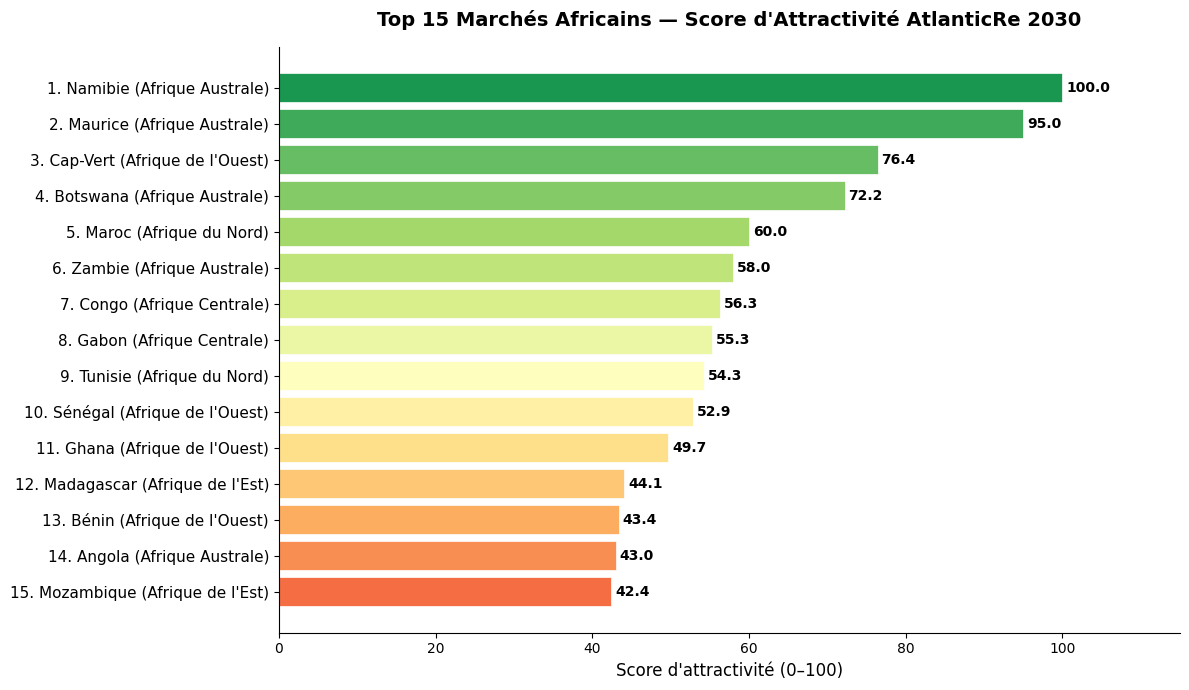

Graphique sauvegardé: attractivite_2030_top15.png


In [27]:
# ── VIZ 1 : TOP 15 SCORE ATTRACTIVITÉ 2030 ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
top15 = df_score.head(15)

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 15))[::-1]
bars = ax.barh(range(len(top15)), top15['score_attractivite_100'], color=colors, edgecolor='white', linewidth=0.5)

ax.set_yticks(range(len(top15)))
ax.set_yticklabels([f"{i+1}. {r['Pays']} ({r['Region']})" 
                    for i, (_, r) in enumerate(top15.iterrows())], fontsize=11)
ax.invert_yaxis()

for i, bar in enumerate(bars):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{top15.iloc[i]['score_attractivite_100']:.1f}",
            va='center', fontsize=10, fontweight='bold')

ax.set_xlabel("Score d'attractivité (0–100)", fontsize=12)
ax.set_title("Top 15 Marchés Africains — Score d'Attractivité AtlanticRe 2030", 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 115)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('attractivite_2030_top15.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé: attractivite_2030_top15.png")

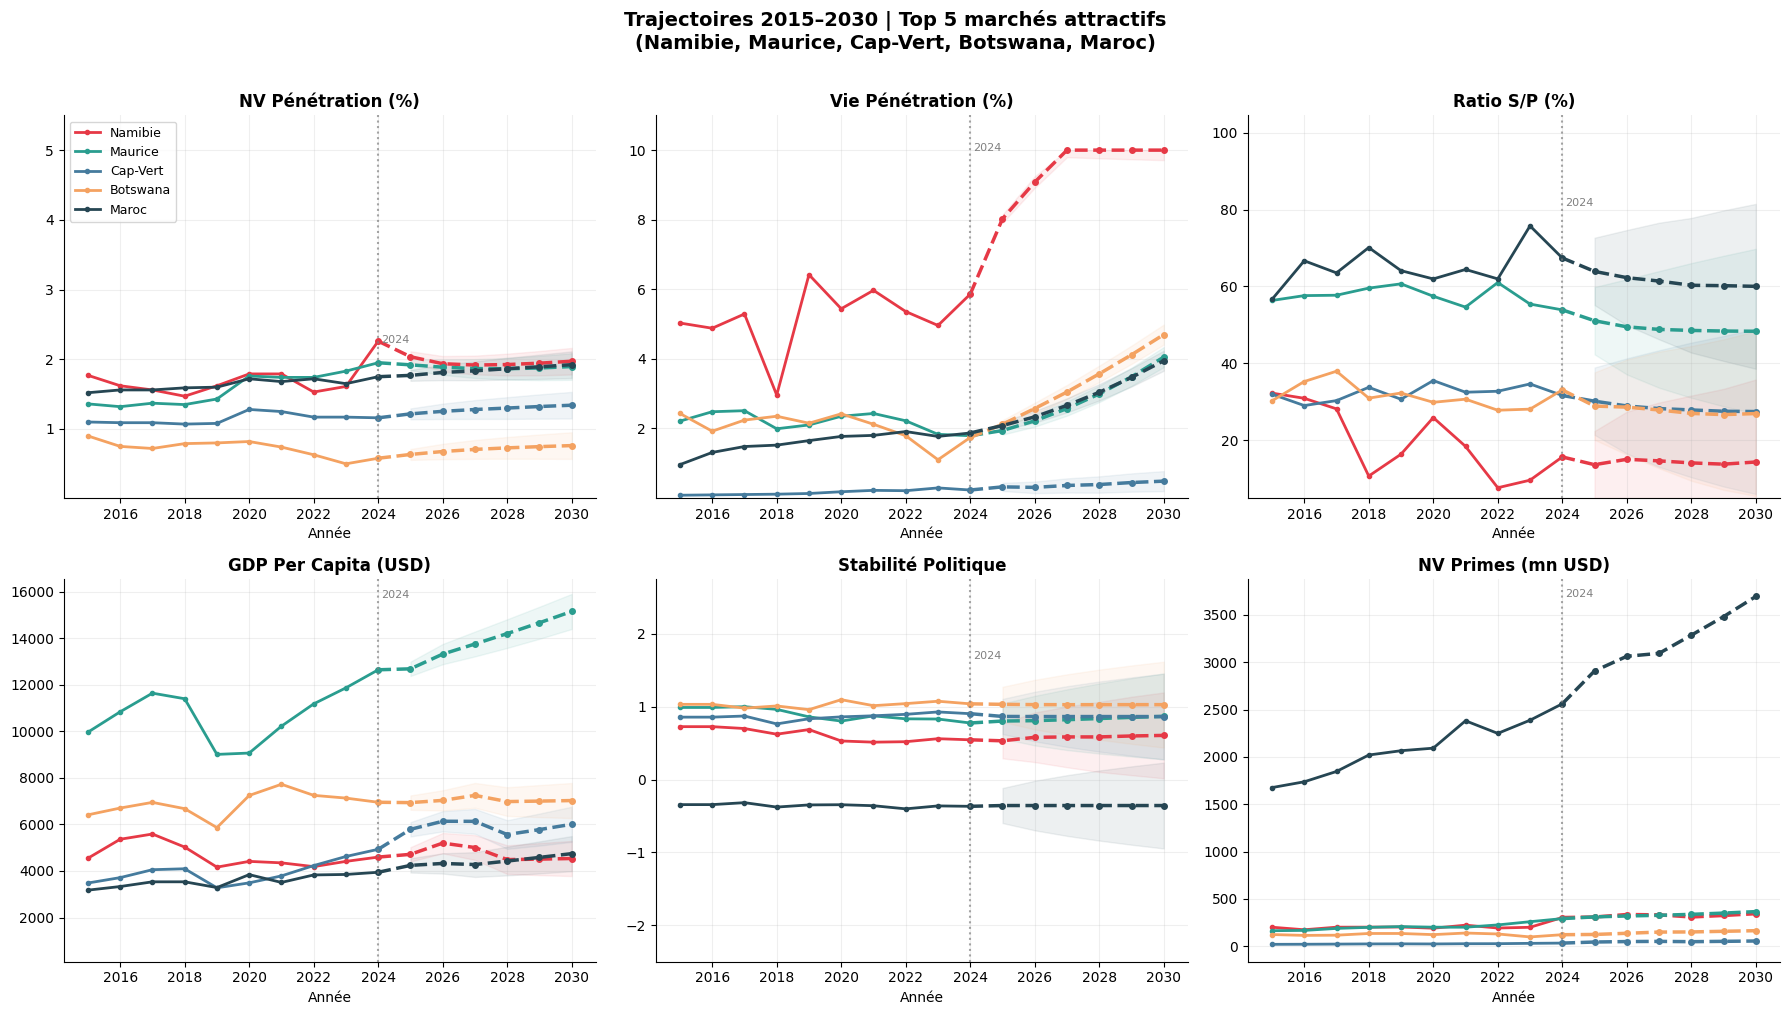

Graphique sauvegardé: trajectoires_top5_2015_2030.png


In [28]:
# ── VIZ 2 : TRAJECTOIRES 2015–2030 POUR LES 5 MEILLEURS MARCHÉS ──────────────
TOP5_PAYS = df_score['Pays'].head(5).tolist()
ALL_YEARS_PLOT = YEARS_HIST + YEARS_PRED

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors_top5 = ['#e63946','#2a9d8f','#457b9d','#f4a261','#264653']

VARS_PLOT = [
    ('nv_penetration',  nv_penet_pred,  'nv_penetration_pred',  'NV Pénétration (%)',  NV_PENET_MIN, NV_PENET_MAX),
    ('vie_penetration', vie_penet_pred, 'vie_penetration_pred', 'Vie Pénétration (%)', VIE_PENET_MIN, 10),
    ('nv_sp',           nv_sp_pred,     'nv_sp_pred',           'Ratio S/P (%)',       NV_SP_MIN, NV_SP_MAX),
    ('gdpcap',          gdpcap_pred,    'gdpcap_pred',          'GDP Per Capita (USD)',100, None),
    ('polstab',         gp_preds['polstab'], 'polstab_pred',    'Stabilité Politique', -2.5, 2.5),
    ('nv_primes',       nv_primes_pred, 'nv_primes_pred',       'NV Primes (mn USD)',  None, None),
]

for ax_idx, (var, pred_dict, pred_col, label, ymin, ymax) in enumerate(VARS_PLOT):
    ax = axes[ax_idx]
    
    for ci, pays in enumerate(TOP5_PAYS):
        vals = [pred_dict[pays].get(yr, np.nan) for yr in ALL_YEARS_PLOT]
        ax.plot(ALL_YEARS_PLOT[:10], vals[:10], color=colors_top5[ci],
                linewidth=2, marker='o', markersize=3, label=pays)
        ax.plot(ALL_YEARS_PLOT[9:], vals[9:], color=colors_top5[ci],
                linewidth=2.5, linestyle='--', marker='o', markersize=4)
        
        # IC 80% pour les prédictions (utiliser conformal_q si disponible)
        if var in conformal_q and pred_col in df_pred.columns:
            q80 = conformal_q.get(var, {}).get('q80', 0)
            lower = [max(pred_dict[pays].get(yr, np.nan) - q80*np.sqrt(yr-2024), ymin or 0)
                     for yr in YEARS_PRED]
            upper = [min(pred_dict[pays].get(yr, np.nan) + q80*np.sqrt(yr-2024), ymax or 1e9)
                     for yr in YEARS_PRED]
            ax.fill_between(YEARS_PRED, lower, upper, alpha=0.08, color=colors_top5[ci])

    ax.axvline(x=2024, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.text(2024.1, ax.get_ylim()[1]*0.95, '2024', color='gray', fontsize=8)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Année')
    if ymin is not None: ax.set_ylim(bottom=ymin)
    if ymax is not None: ax.set_ylim(top=ymax*1.1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.2)
    if ax_idx == 0:
        ax.legend(fontsize=9, loc='upper left')

plt.suptitle(f"Trajectoires 2015–2030 | Top 5 marchés attractifs\n({', '.join(TOP5_PAYS)})",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('trajectoires_top5_2015_2030.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé: trajectoires_top5_2015_2030.png")

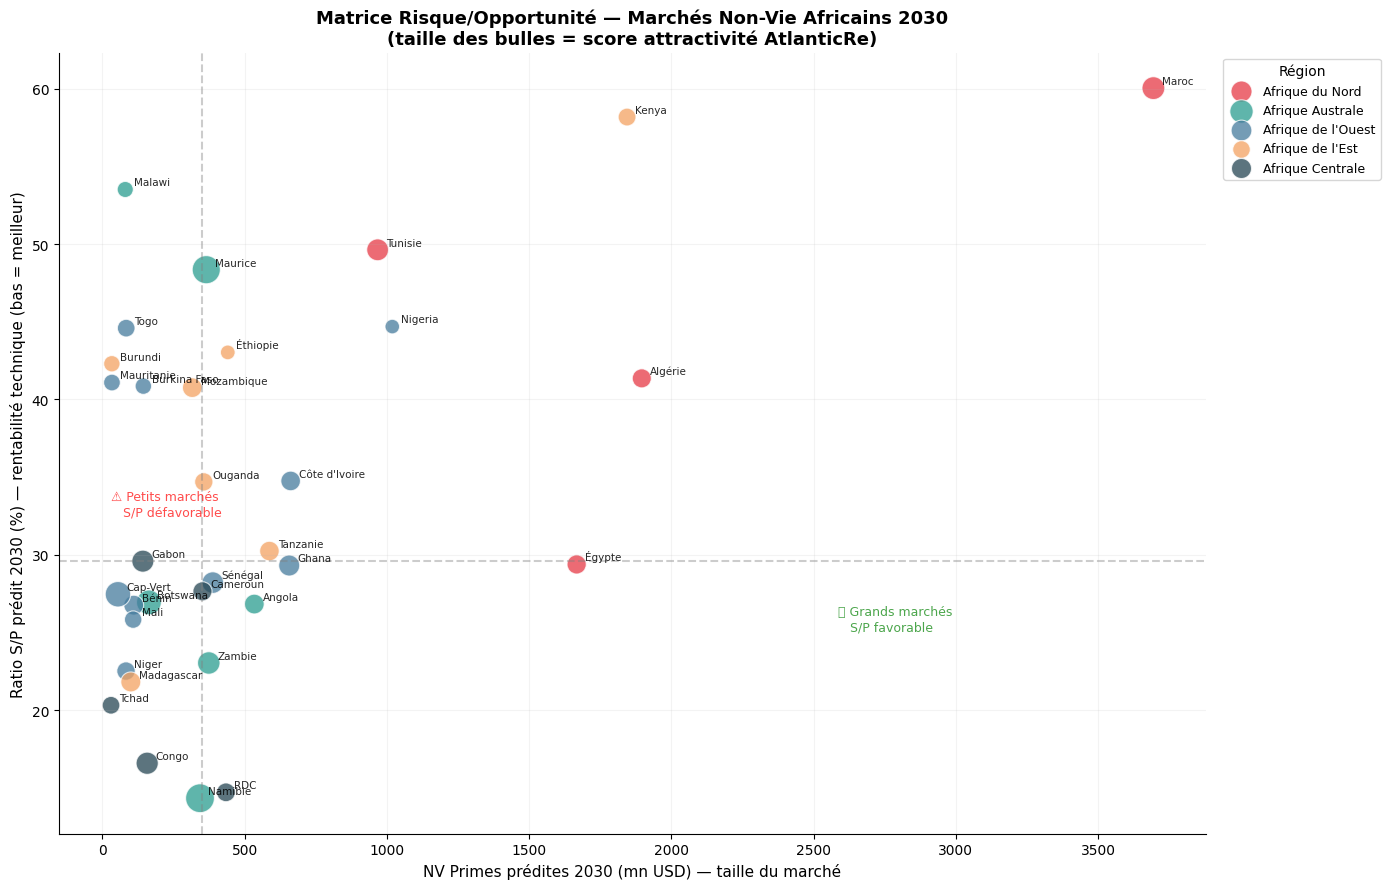

Graphique sauvegardé: matrice_risque_opportunite_2030.png


In [29]:
# ── VIZ 3 : SCATTER NV_PRIMES vs NV_SP 2030 (vue risque/opportunité) ─────────
fig, ax = plt.subplots(figsize=(14, 9))

scatter_data = df_2030[['Pays','Region','nv_primes_pred','nv_sp_pred','score_attractivite_100']].dropna()

regions_unique = scatter_data['Region'].unique()
palette = dict(zip(regions_unique, ['#e63946','#2a9d8f','#457b9d','#f4a261','#264653']))

for region in regions_unique:
    sub = scatter_data[scatter_data['Region']==region]
    sc = ax.scatter(sub['nv_primes_pred'], sub['nv_sp_pred'],
                    s=sub['score_attractivite_100']*4 + 30,
                    c=palette.get(region,'#888'),
                    alpha=0.75, edgecolors='white', linewidths=0.8, label=region)

for _, row in scatter_data.iterrows():
    ax.annotate(row['Pays'], (row['nv_primes_pred'], row['nv_sp_pred']),
                textcoords='offset points', xytext=(6, 3), fontsize=7.5, alpha=0.85)

# Quadrants
med_primes = scatter_data['nv_primes_pred'].median()
med_sp     = scatter_data['nv_sp_pred'].median()
ax.axvline(med_primes, color='gray', linestyle='--', alpha=0.4)
ax.axhline(med_sp,     color='gray', linestyle='--', alpha=0.4)

ax.text(scatter_data['nv_primes_pred'].max()*0.7, med_sp*0.85,
        '✅ Grands marchés\n   S/P favorable', fontsize=9, color='green', alpha=0.7)
ax.text(scatter_data['nv_primes_pred'].min()*1.05, med_sp*1.1,
        '⚠️ Petits marchés\n   S/P défavorable', fontsize=9, color='red', alpha=0.7)

ax.set_xlabel('NV Primes prédites 2030 (mn USD) — taille du marché', fontsize=11)
ax.set_ylabel('Ratio S/P prédit 2030 (%) — rentabilité technique (bas = meilleur)', fontsize=11)
ax.set_title('Matrice Risque/Opportunité — Marchés Non-Vie Africains 2030\n(taille des bulles = score attractivité AtlanticRe)',
             fontsize=13, fontweight='bold')
ax.legend(title='Région', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig('matrice_risque_opportunite_2030.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé: matrice_risque_opportunite_2030.png")

In [30]:
# ── VIZ 4 : TABLEAU RÉCAPITULATIF DES MÉTRIQUES DE VALIDATION ─────────────────
print("\n" + "="*80)
print("TABLEAU RÉCAPITULATIF — MÉTRIQUES DE VALIDATION WALK-FORWARD")
print("="*80)

TARGET_LABELS = {
    'nv_penetration':  'NV Pénétration',
    'vie_penetration': 'Vie Pénétration',
    'gdpcap':          'GDP Per Capita',
    'polstab':         'Stabilité Politique',
    'regqual':         'Qualité Réglementaire',
    'nv_sp':           'Ratio S/P'
}
MODELE_LABELS = {
    'nv_penetration':  'FE-OLS + RidgeCV + ARIMA(1,0,0)',
    'vie_penetration': 'FE-OLS + RidgeCV + ARIMA(1,0,0)',
    'gdpcap':          'FE-OLS + RidgeCV + ARIMA(1,0,0)',
    'polstab':         'Gaussian Process (RBF + WhiteKernel)',
    'regqual':         'Gaussian Process (RBF + WhiteKernel)',
    'nv_sp':           'AR(2) + RidgeCV + XGBoost résidus'
}

print(f"{'Variable':<22} {'Modèle':<38} {'R²':>7} {'MAPE%':>8} {'q80':>8} {'q95':>8}")
print("-"*97)
for var in TARGET_VARS:
    label = TARGET_LABELS.get(var, var)
    modele = MODELE_LABELS.get(var, '—')
    r2_m = np.mean(wf_metrics[var]['r2']) if wf_metrics[var]['r2'] else np.nan
    mape_m = np.mean(wf_metrics[var]['mape']) if wf_metrics[var]['mape'] else np.nan
    q80 = conformal_q.get(var, {}).get('q80', np.nan)
    q95 = conformal_q.get(var, {}).get('q95', np.nan)
    print(f"{label:<22} {modele:<38} {r2_m:>7.3f} {mape_m:>8.1f} {q80:>8.3f} {q95:>8.3f}")

print("\n" + "="*80)
print("PRÉDICTIONS 2030 — RÉSUMÉ PAR VARIABLE (moyennes continentales)")
print("="*80)

df_2030_summary = df_pred[df_pred['Year']==2030][[
    'nv_penetration_pred','vie_penetration_pred','nv_sp_pred',
    'gdpcap_pred','polstab_pred','regqual_pred',
    'nv_primes_pred','vie_primes_pred'
]].agg(['mean','median','min','max']).round(3)
print(df_2030_summary.to_string())


TABLEAU RÉCAPITULATIF — MÉTRIQUES DE VALIDATION WALK-FORWARD
Variable               Modèle                                      R²    MAPE%      q80      q95
-------------------------------------------------------------------------------------------------
NV Pénétration         FE-OLS + RidgeCV + ARIMA(1,0,0)          0.954     10.0    0.078    0.204
Vie Pénétration        FE-OLS + RidgeCV + ARIMA(1,0,0)          0.922     25.8    0.118    0.650
GDP Per Capita         FE-OLS + RidgeCV + ARIMA(1,0,0)          0.980      9.0  307.911  706.173
Stabilité Politique    Gaussian Process (RBF + WhiteKernel)     0.945     45.7    0.240    0.385
Qualité Réglementaire  Gaussian Process (RBF + WhiteKernel)     0.971    140.3    0.108    0.201
Ratio S/P              AR(2) + RidgeCV + XGBoost résidus        0.738     20.0    8.753   17.987

PRÉDICTIONS 2030 — RÉSUMÉ PAR VARIABLE (moyennes continentales)
        nv_penetration_pred  vie_penetration_pred  nv_sp_pred  gdpcap_pred  polstab_pred  regqua

In [31]:
# ── APERÇU FINAL : TOP 10 PAYS PRÉDIT 2030 ───────────────────────────────────
print("\n" + "="*110)
print("PRÉDICTIONS 2030 — TOP 10 PAYS PAR SCORE D'ATTRACTIVITÉ")
print("="*110)

cols_display = ['Pays','Region','score_attractivite_100',
                'nv_penetration_pred','nv_sp_pred','vie_penetration_pred',
                'gdpcap_pred','polstab_pred','regqual_pred',
                'nv_primes_pred','vie_primes_pred']
print(df_score[cols_display].head(10).to_string(index=True))

print("\n" + "="*110)
print("BOTTOM 5 PAYS (marchés les moins attractifs en 2030)")
print("="*110)
print(df_score[cols_display].tail(5).to_string(index=True))

print("\n✅  MODÈLE COMPLET — Toutes les étapes exécutées avec succès.")
print("📄 Fichiers générés:")
print("   - predictions_2025_2030_AtlanticRe.csv")
print("   - score_attractivite_2030_AtlanticRe.csv")
print("   - attractivite_2030_top15.png")
print("   - trajectoires_top5_2015_2030.png")
print("   - matrice_risque_opportunite_2030.png")


PRÉDICTIONS 2030 — TOP 10 PAYS PAR SCORE D'ATTRACTIVITÉ
        Pays              Region  score_attractivite_100  nv_penetration_pred  nv_sp_pred  vie_penetration_pred  gdpcap_pred  polstab_pred  regqual_pred  nv_primes_pred  vie_primes_pred
1    Namibie    Afrique Australe                   100.0               1.9720       14.35               10.0000       4536.4         0.605        -0.016          343.04          1739.53
2    Maurice    Afrique Australe                    95.0               1.8956       48.35                4.0513      15155.5         0.866         1.105          365.03           780.16
3   Cap-Vert  Afrique de l'Ouest                    76.4               1.3409       27.47                0.4847       6007.7         0.864         0.054           54.54            19.72
4   Botswana    Afrique Australe                    72.2               0.7616       26.95                4.6978       7027.0         1.027         0.580          163.43          1008.06
5      Maroc 

In [ ]:
# ── VALIDATION POST-CORRECTIONS ──────────────────────────────────────────────
print("=== VALIDATION POST-CORRECTIONS ===\n")

# 1. WGI : vérifier que les projections sont stables et dans [-2.5, 2.5]
for var in ['polstab', 'regqual']:
    vals_2030 = [gp_preds[var][p][2030] for p in PAYS_33]
    print(f"{var} 2030 — min={min(vals_2030):.3f} | max={max(vals_2030):.3f} | "
          f"hors_bornes={sum(1 for v in vals_2030 if abs(v) > 2.5)}")

# 2. vie_penetration : vérifier MAPE sur dernière année connue (2024)
vie_errs = []
for pays in PAYS_33:
    df_p = df[df['Pays'] == pays]
    row = df_p[df_p['Year'] == 2024]
    if len(row) > 0:
        actual = float(row['vie_penetration'].values[0])
        pred   = vie_penet_pred[pays][2024]
        if actual > 0:
            vie_errs.append(abs(pred - actual) / actual)
if vie_errs:
    print(f"\nvie_penetration MAPE 2024 (in-sample check) : {np.mean(vie_errs)*100:.1f}%")

# 3. nv_sp : vérifier tendance et biais
sp_2025 = np.mean([nv_sp_pred[p][2025] for p in PAYS_33])
sp_2030 = np.mean([nv_sp_pred[p][2030] for p in PAYS_33])
sp_2024_hist = df[df['Year']==2024]['nv_sp'].mean()
print(f"\nnv_sp moyen — historique 2024: {sp_2024_hist:.1f}% | prédit 2025: {sp_2025:.1f}% | prédit 2030: {sp_2030:.1f}%")
print(f"Tendance implicite 2025→2030 : {(sp_2030-sp_2025)/5:.2f} pp/an (attendu ~−0.69)")

# 4. Aucune valeur aberrante
for pays in PAYS_33:
    for yr in YEARS_PRED:
        assert 0.001 <= vie_penet_pred[pays][yr] <= 10.0, f"vie_penetration hors bornes: {pays} {yr}"
        assert 5.0   <= nv_sp_pred[pays][yr]     <= 95.0, f"nv_sp hors bornes: {pays} {yr}"
        for var in ['polstab','regqual']:
            assert -2.5 <= gp_preds[var][pays][yr] <= 2.5, f"{var} hors bornes: {pays} {yr}"

print("\nToutes les assertions passent ✓")
print("=== FIN VALIDATION ===")